# **Project: Clustering for heart disease analysis**

##### **Reference**: [amirabwd18, Azzedine Idir Aitsaid, Mohcen Chouireb, and Omar Farouk Zouak. K-Means Clustering for Heart Disease Analysis. www.kaggle.com/competitions/k-means-clustering-for-heart-disease-analysis/overview/citation](https://www.kaggle.com/competitions/k-means-clustering-for-heart-disease-analysis/overview)

--- 
## **1. Big Picture and Objectives**

- **Objective**: Using unsupervised learning techniques, find the best clustering algorithm that minimizes log loss and allows us to group patients based on common characteristics.
- **Goal**: Identify the most effective clustering technique for the given dataset.
- **Clustering algorithms to explore**: K-Means, Mini-Batch K-Means, DBSCAN, Agglomerative Clustering, Spectral Clustering, Gaussian Mixture Models (GMM), Bayesian Gaussian Mixture Models.
- **Evaluation Metric**:
    - Primary metric: Log Loss, also known as Logistic Loss or Cross-Entropy Loss, is commonly used in machine learning as a performance metric for classification problems. It quantifies the accuracy of a classifier by penalising false classifications.
    - Secondary metrics that will be used in this analysis include: Silhouette Score

---
## **2. Get the data**

In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/clustering_for_heart_disease_analysis_project/heart_disease.csv"
)
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN
916,916,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN
917,917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect
918,918,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN


---
## **3. Exploratory Analysis and Insights**

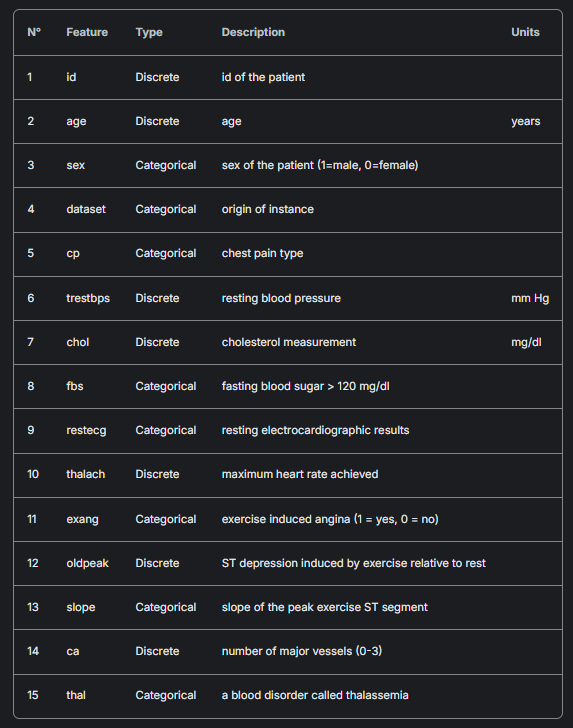

In [125]:
import pandas as pd

# Example: your heart dataframe
# df = pd.read_csv("...")

column_descriptions = {
    "id": "id of the patient",
    "age": "age (years)",
    "sex": "sex of the patient (1=male, 0=female)",
    "dataset": "origin of instance",
    "cp": "chest pain type",
    "trestbps": "resting blood pressure (mm Hg)",
    "chol": "cholesterol measurement (mg/dl)",
    "fbs": "fasting blood sugar > 120 mg/dl",
    "restecg": "resting electrocardiographic results",
    "thalch": "maximum heart rate achieved",
    "exang": "exercise induced angina (1=yes, 0=no)",
    "oldpeak": "ST depression induced by exercise relative to rest",
    "slope": "slope of the peak exercise ST segment",
    "ca": "number of major vessels (0-3)",
    "thal": "thalassemia blood disorder"
}

df.attrs["column_descriptions"] = column_descriptions


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,920.0,459.500000,265.725422,0.0,229.75,459.5,689.25,919.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0


In [5]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

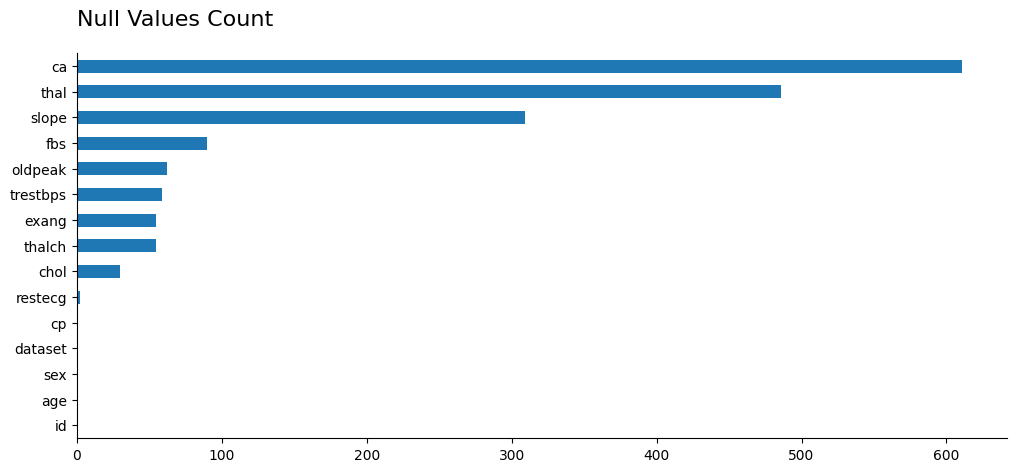

In [6]:
# Null values count
ax = df.isnull().sum().sort_values(ascending=True).plot(
    kind="barh", figsize=(12, 5), 
    )
ax.set_title(
    "Null Values Count",
    fontsize=16,
    loc="left",
    pad=20
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [7]:
# Duplicate rows count
print(f"Duplicate rows count: {df.duplicated().sum()}")

Duplicate rows count: 0


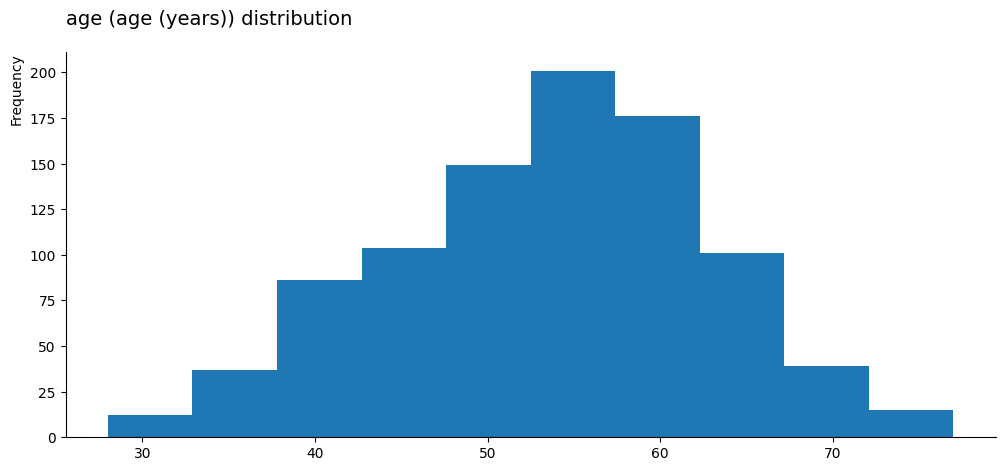

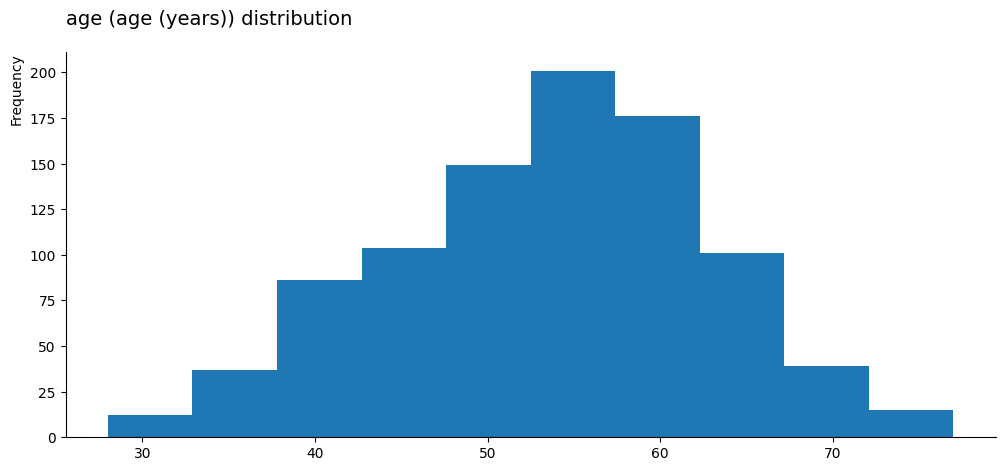

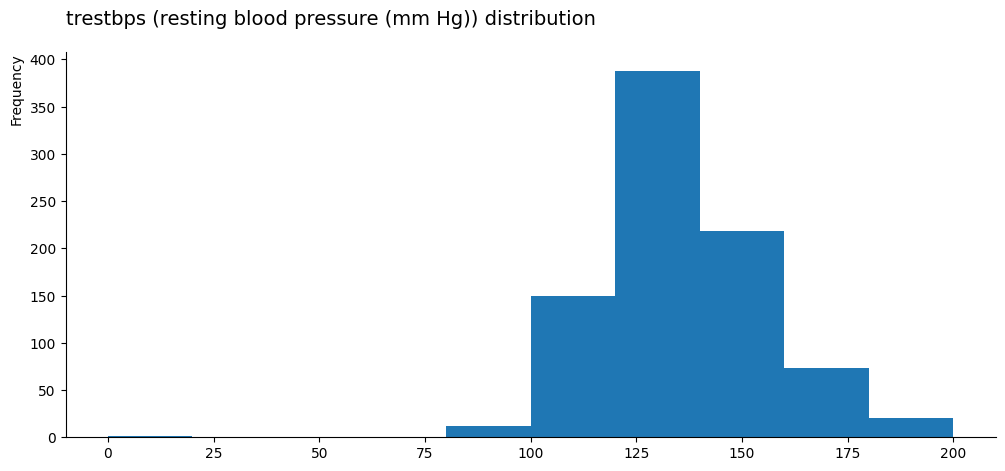

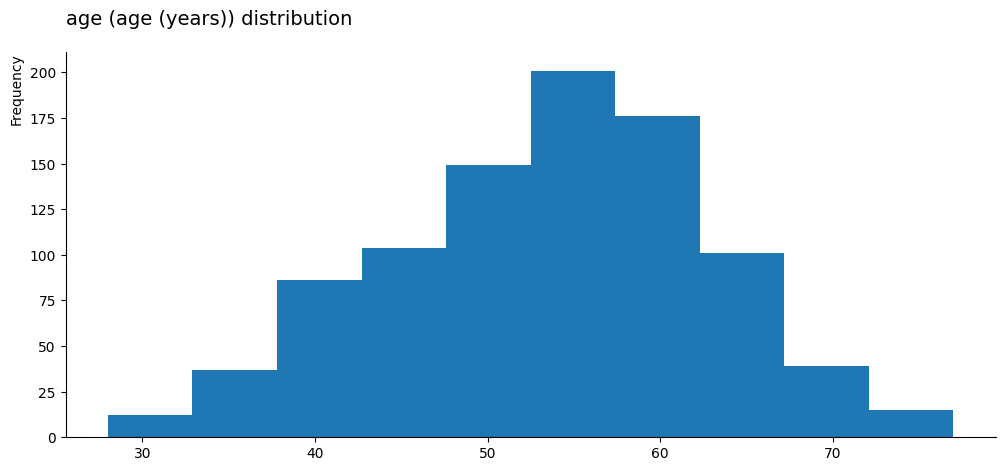

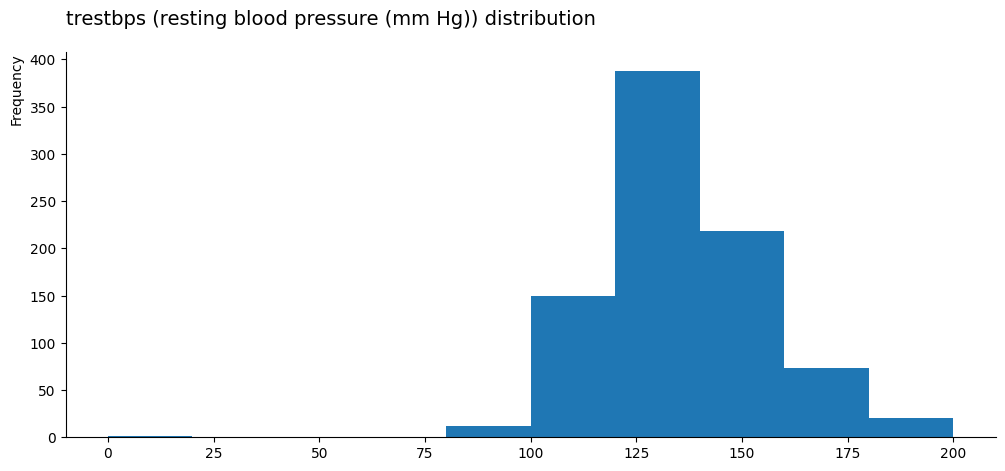

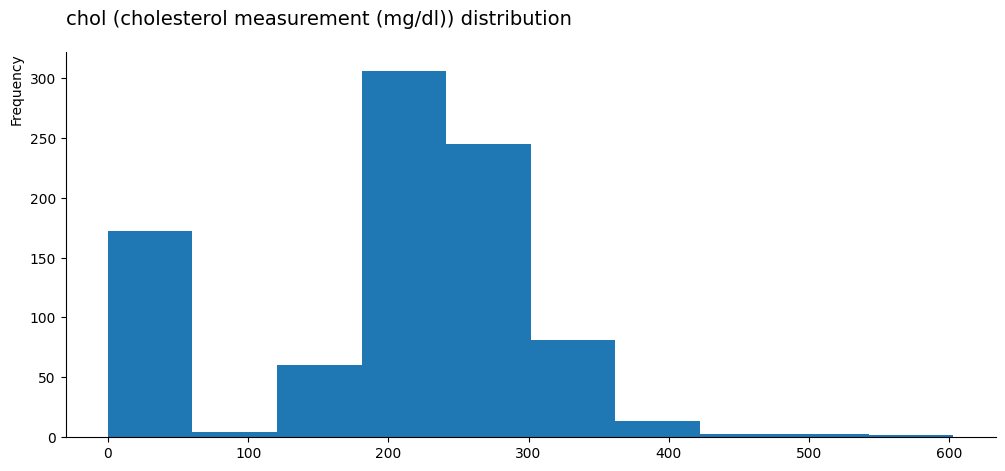

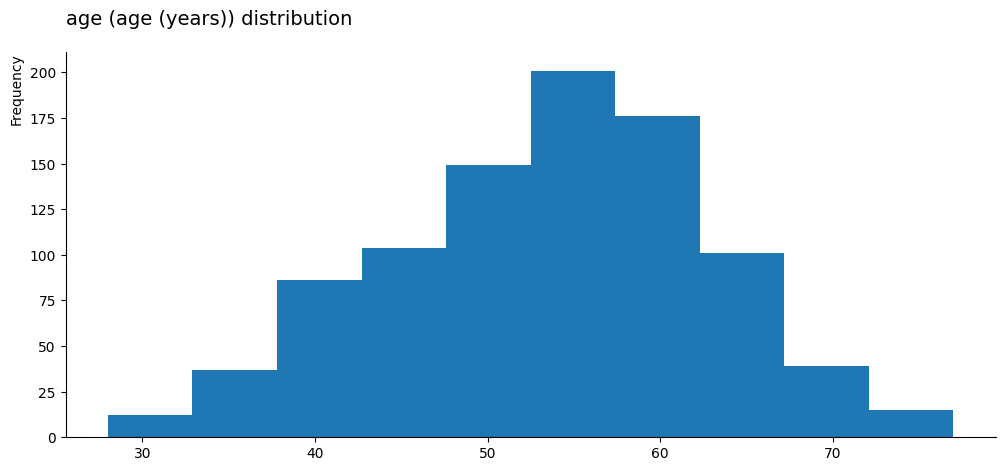

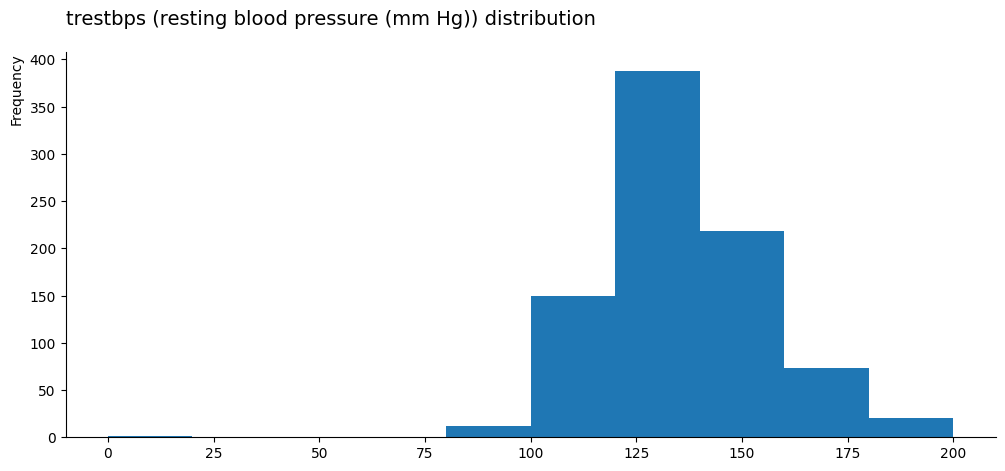

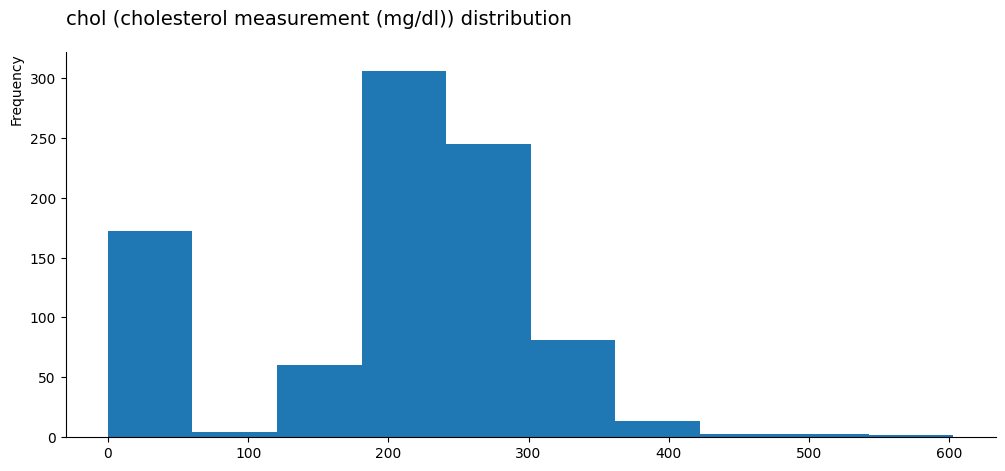

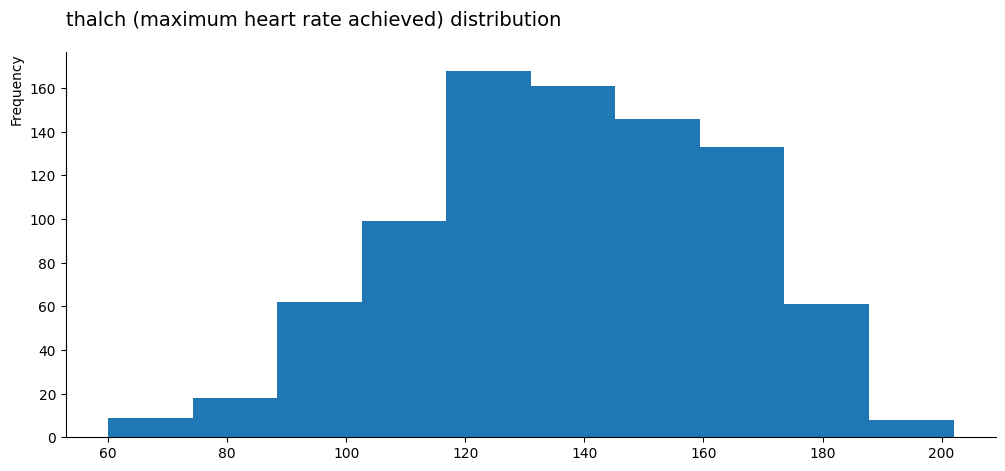

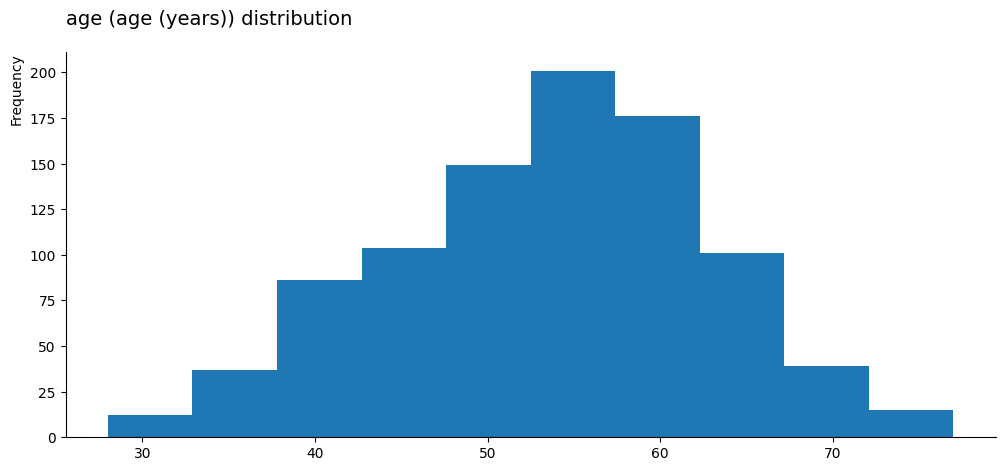

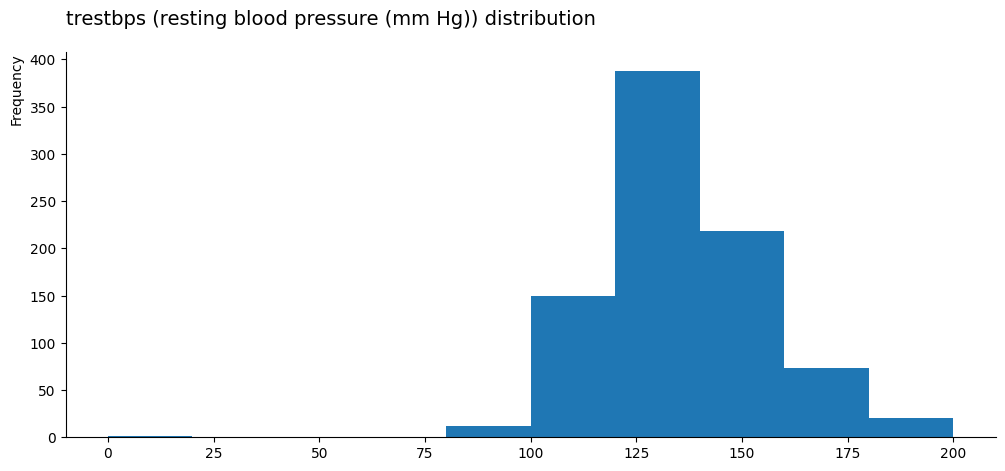

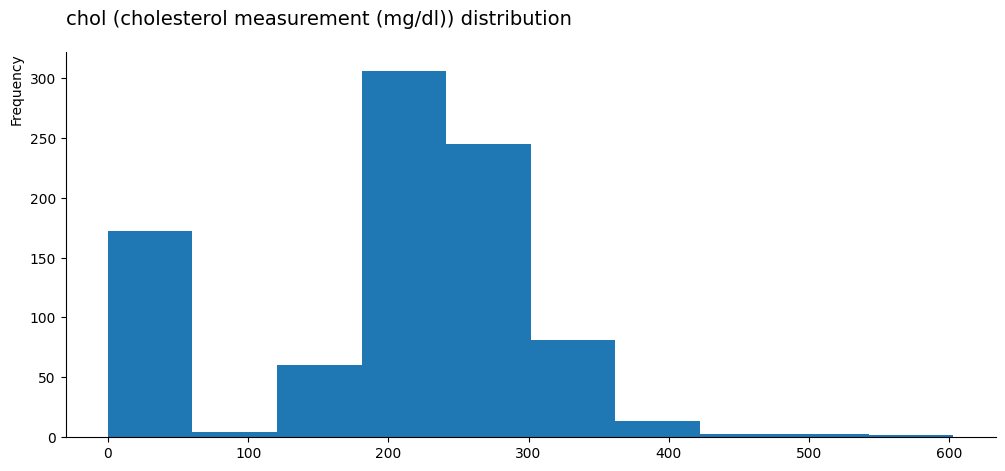

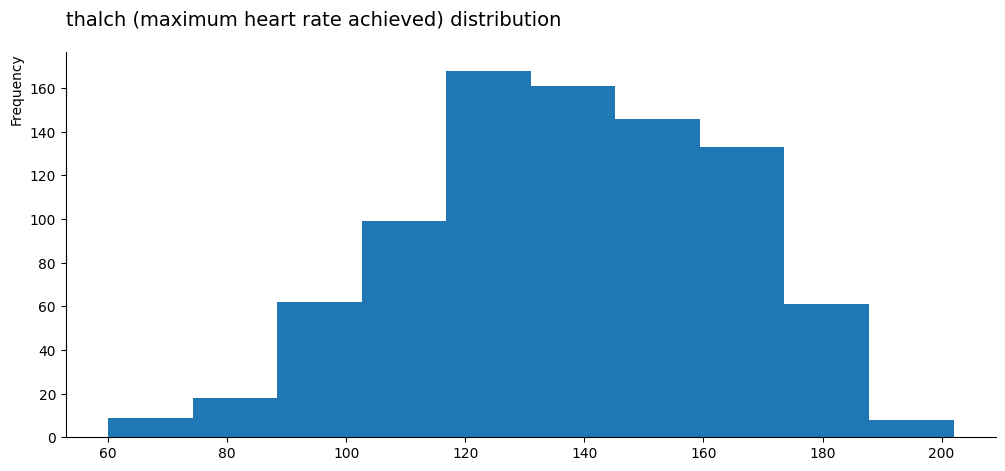

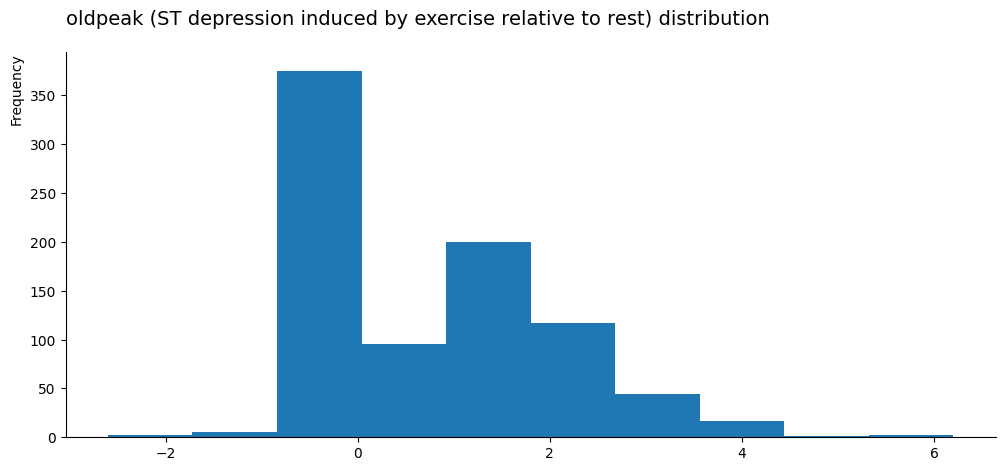

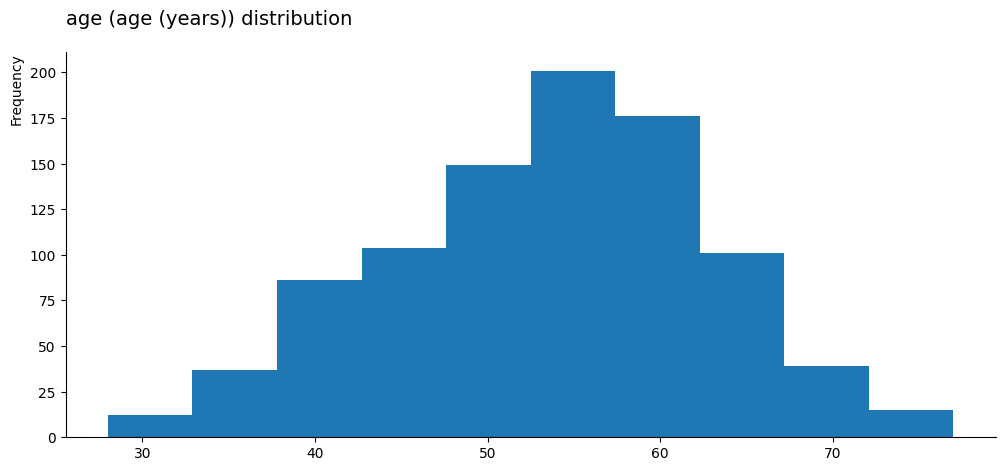

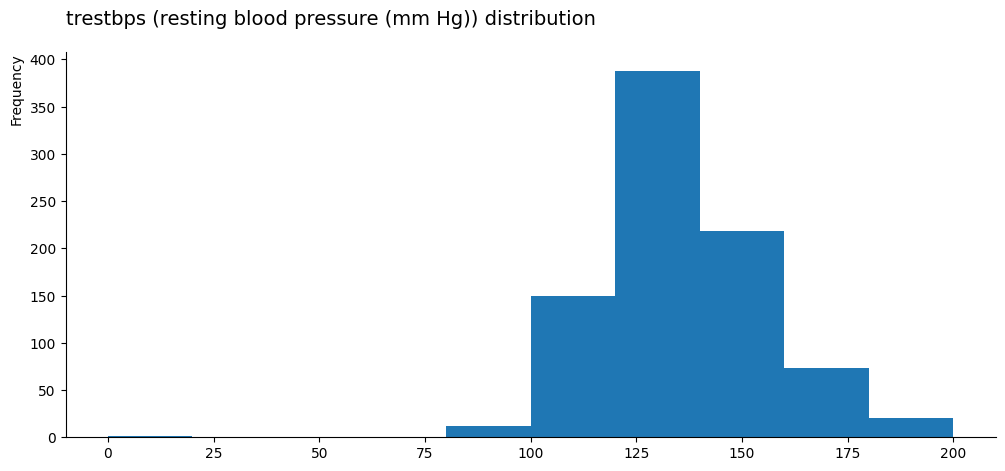

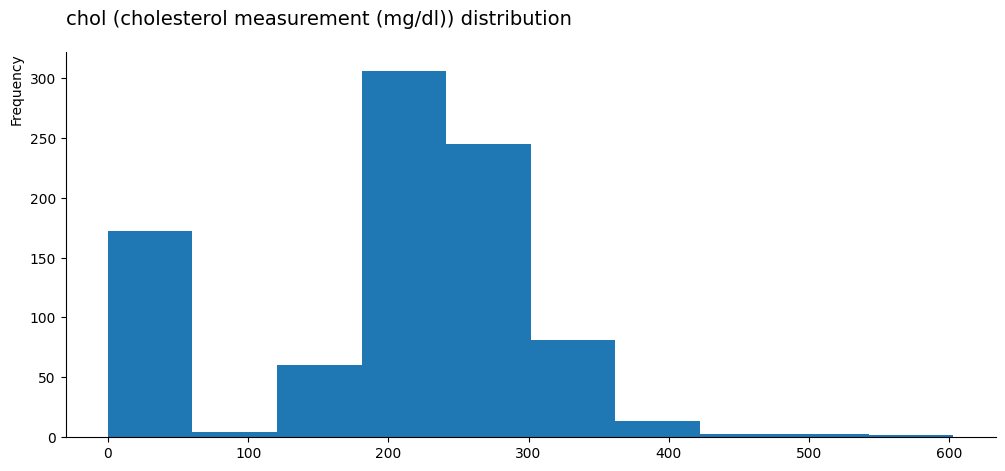

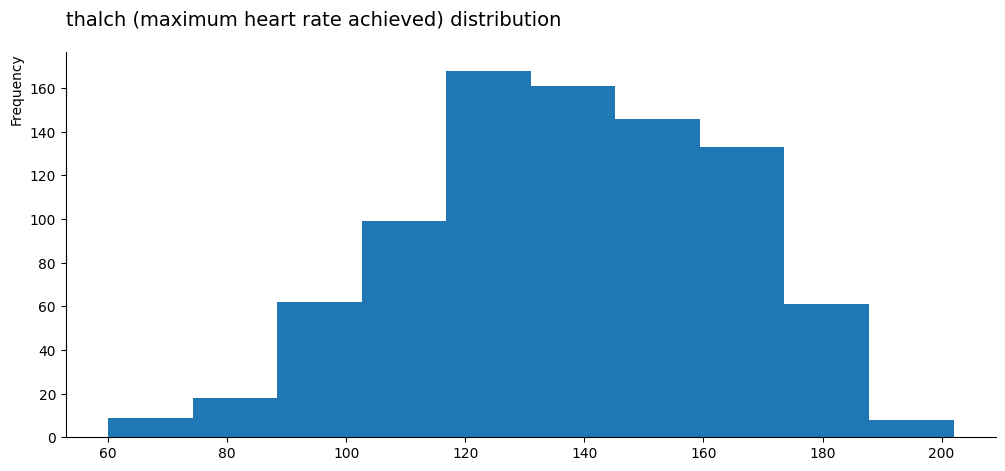

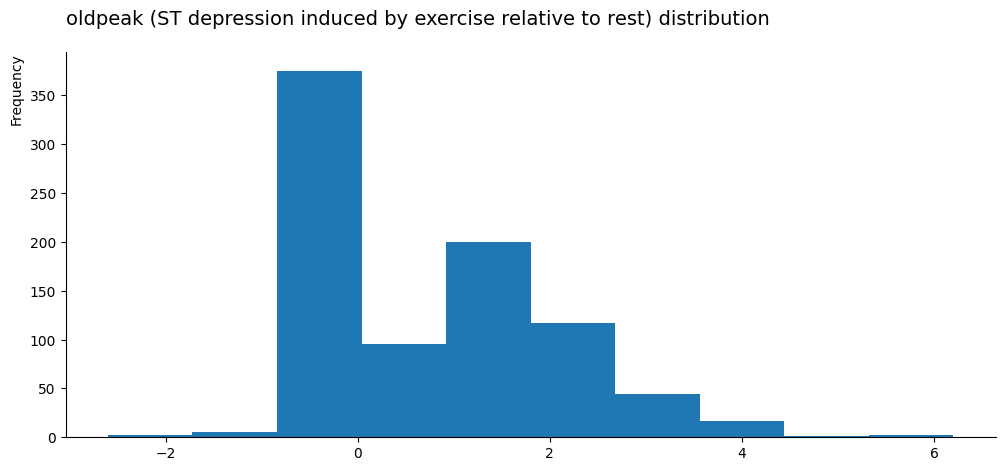

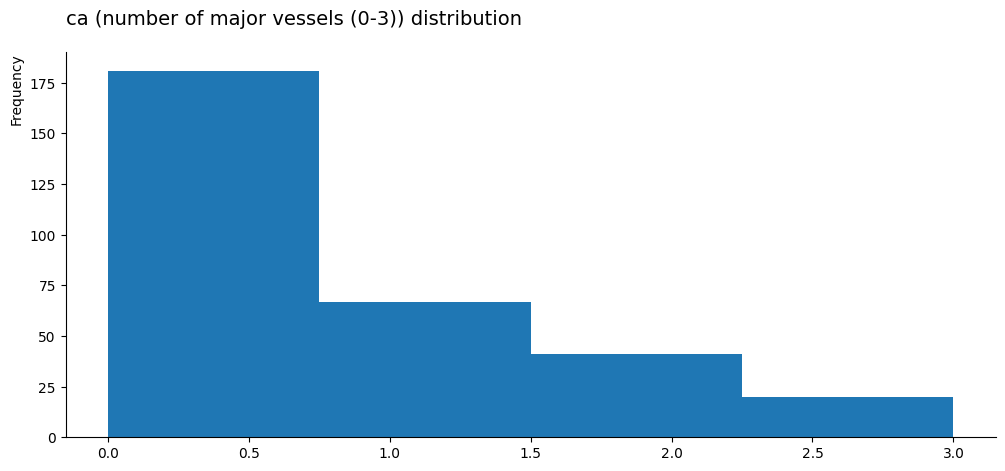

In [8]:
from matplotlib import pyplot as plt

discrete_cols = [
    col for col in df.columns
    if df[col].dtype != "object"
    and col not in ["id"]
]

for col in discrete_cols:
    bins = min(10, df[col].nunique())
    ax = df[col].plot(kind="hist", bins=bins, figsize=(12, 5))
    ax.set_title(
        f"{col} ({df.attrs['column_descriptions'].get(col, '')}) distribution",
        fontsize=14,
        loc="left",
        pad=20
    )
    ax.set_ylabel("Frequency", loc="top")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()

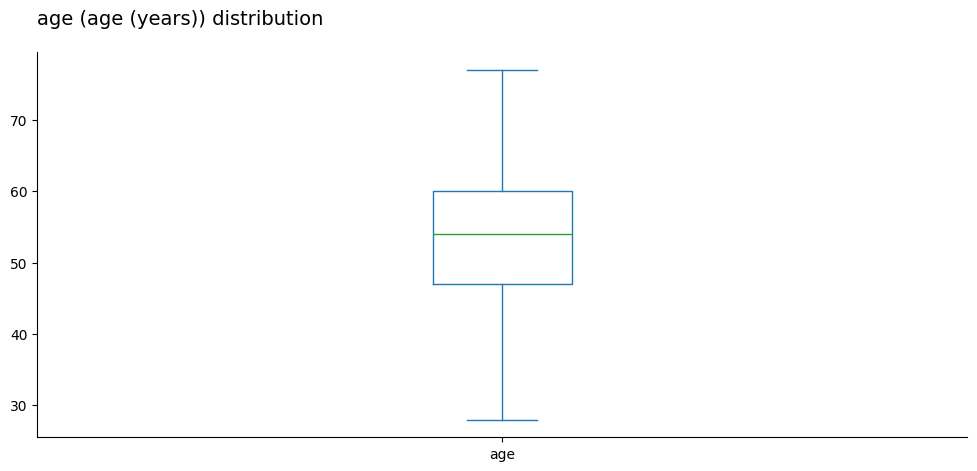

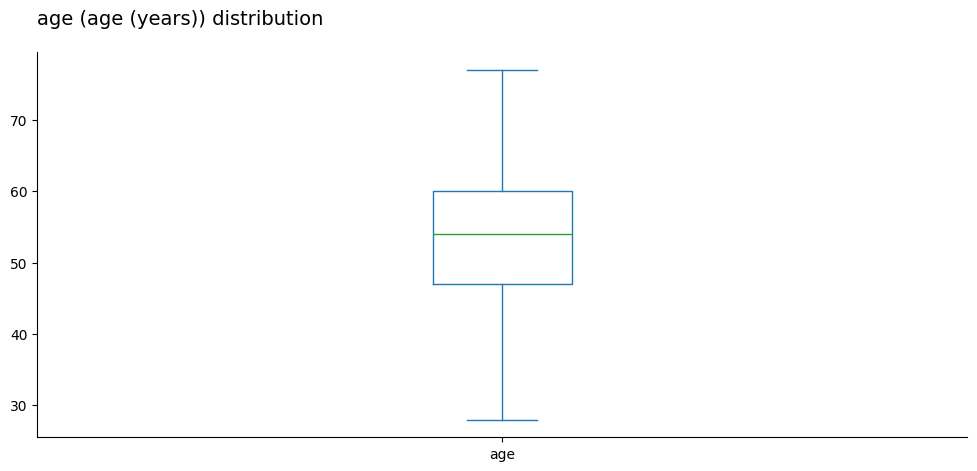

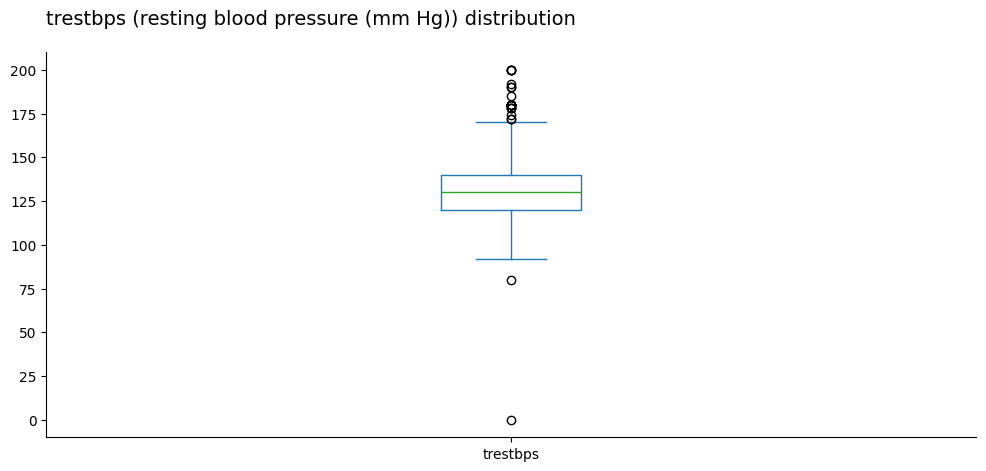

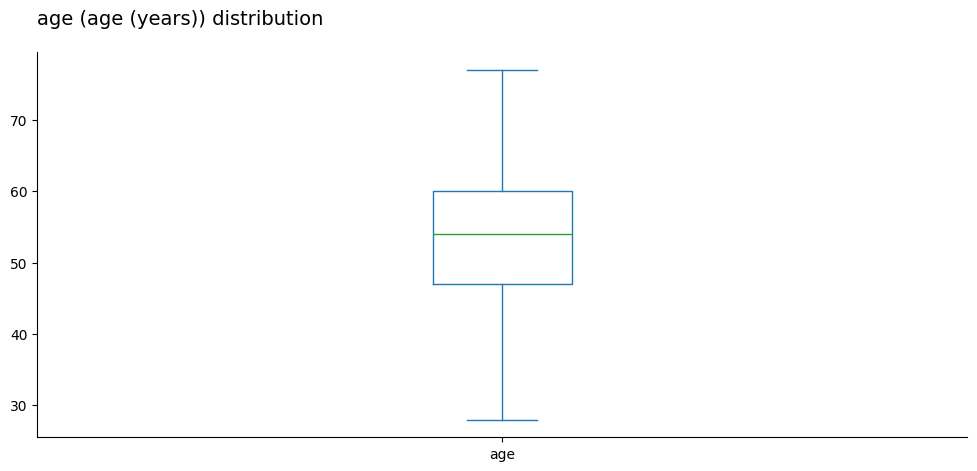

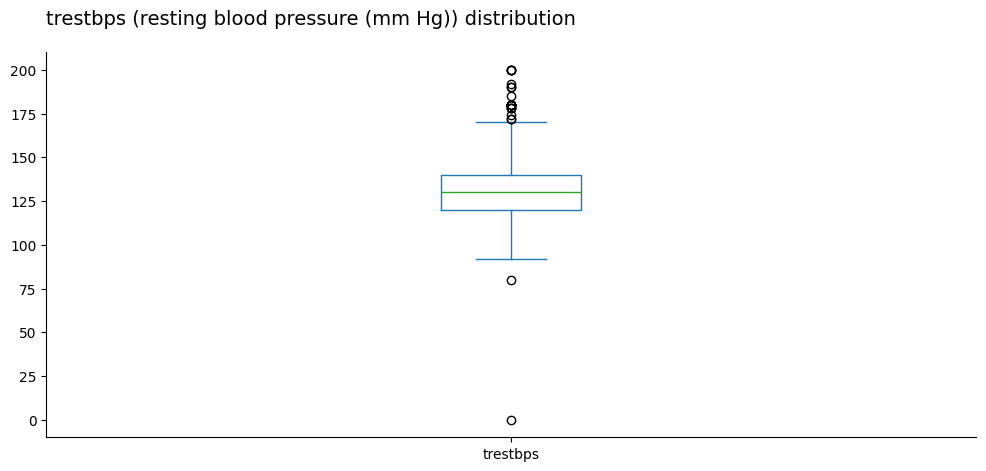

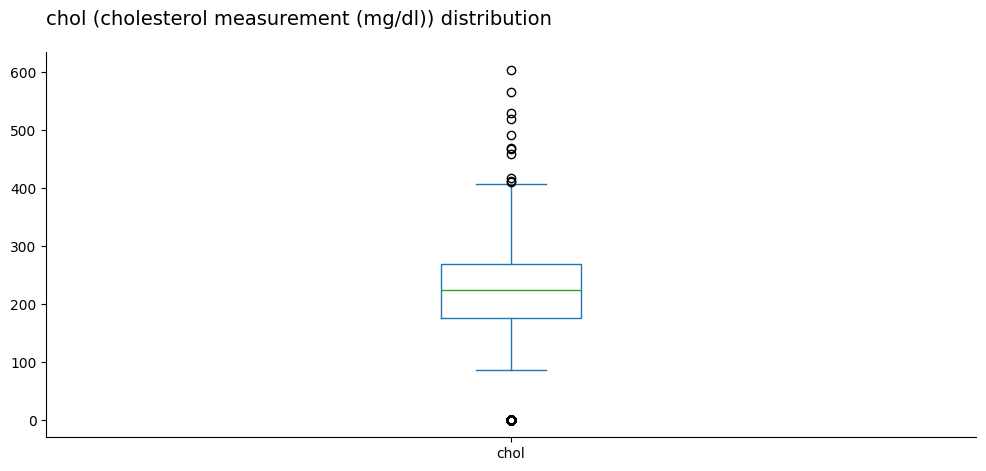

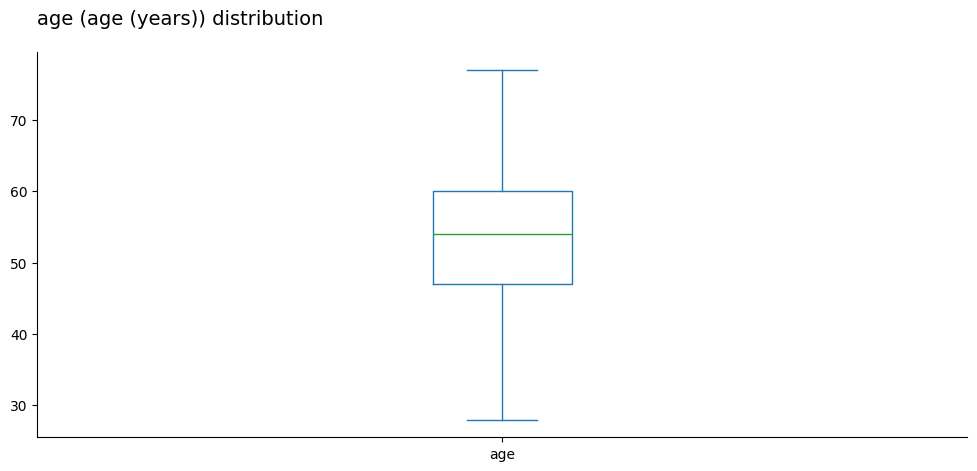

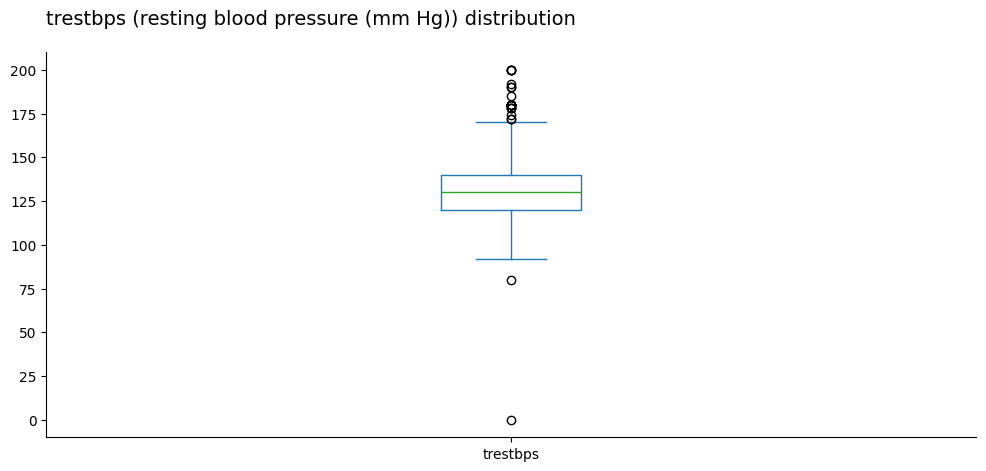

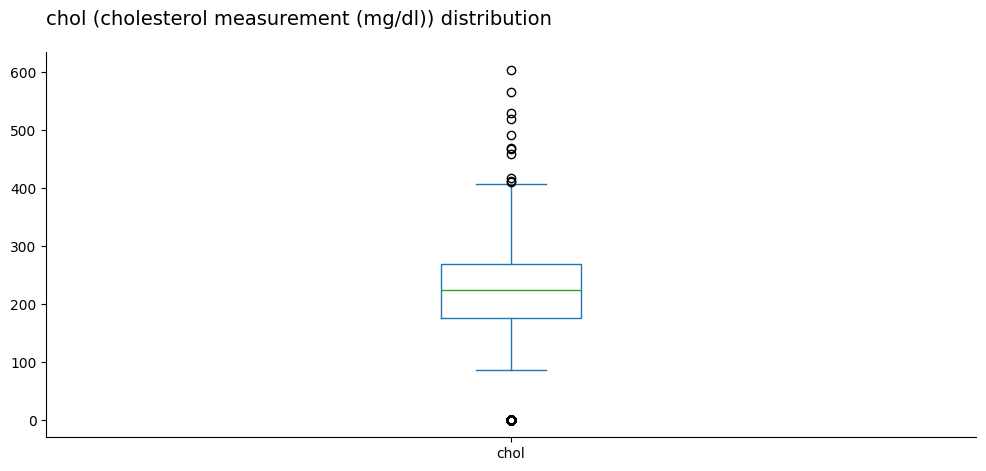

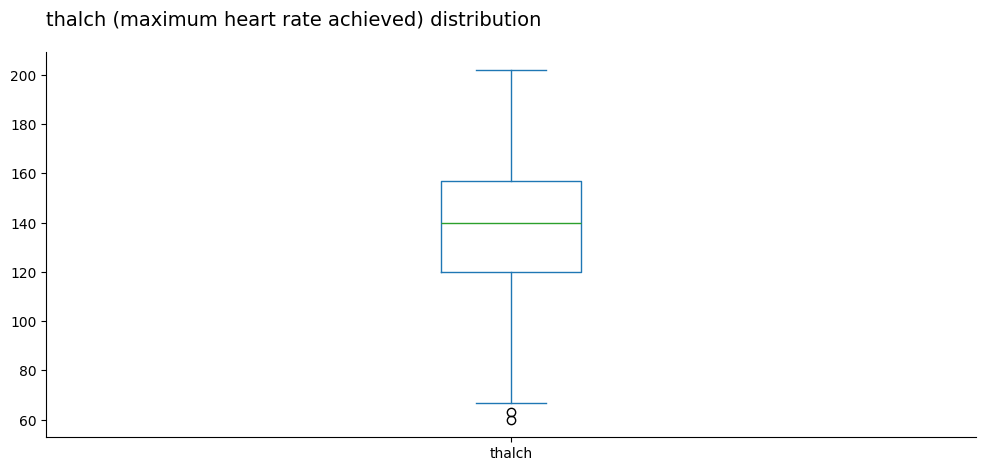

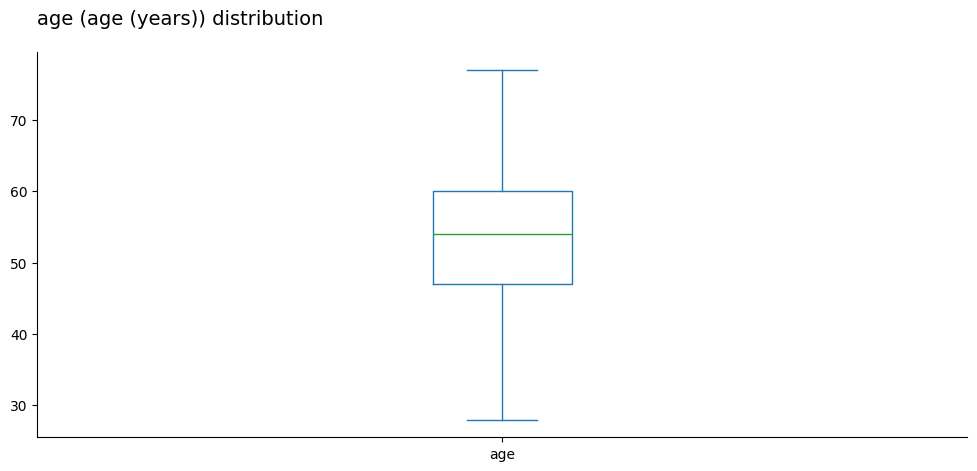

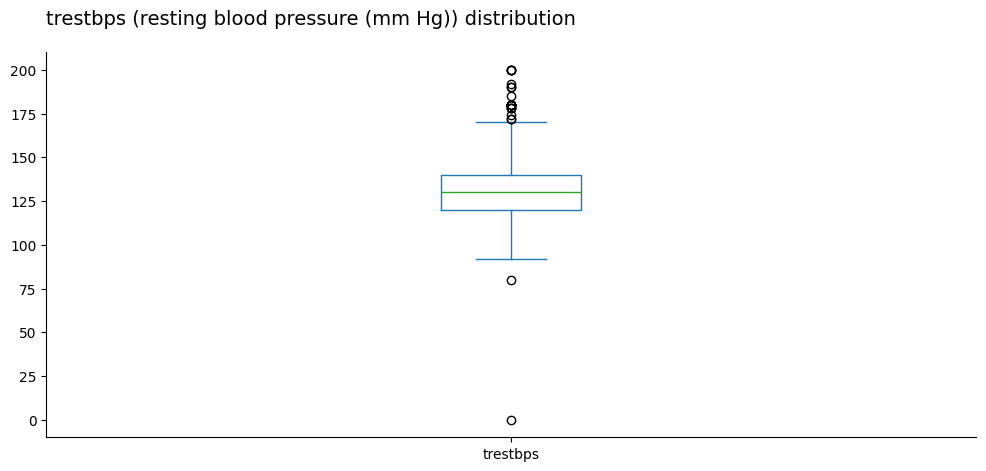

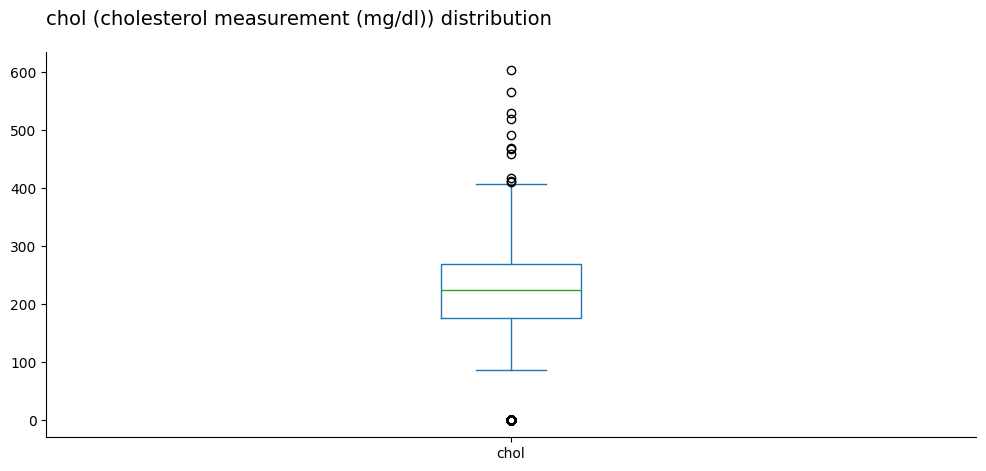

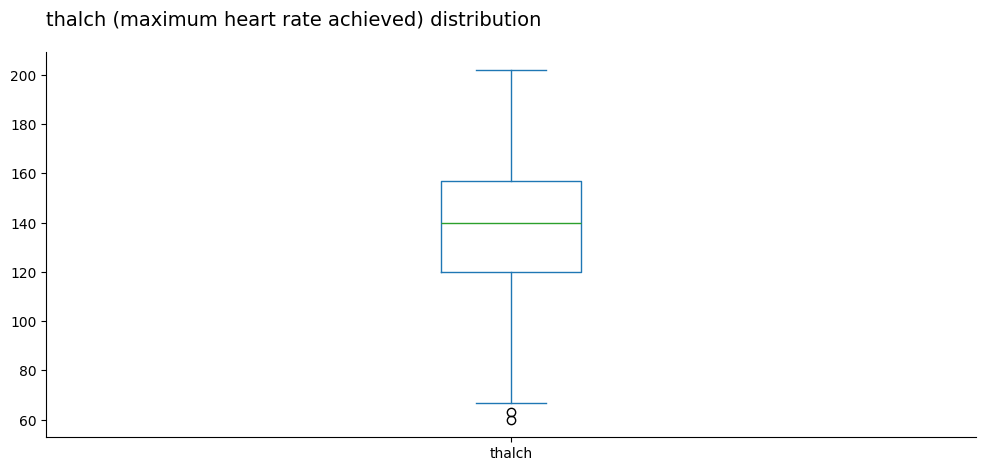

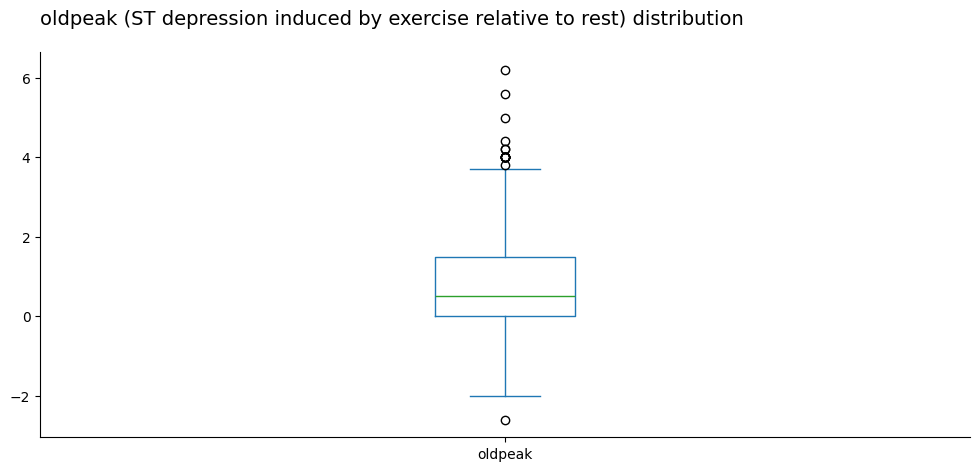

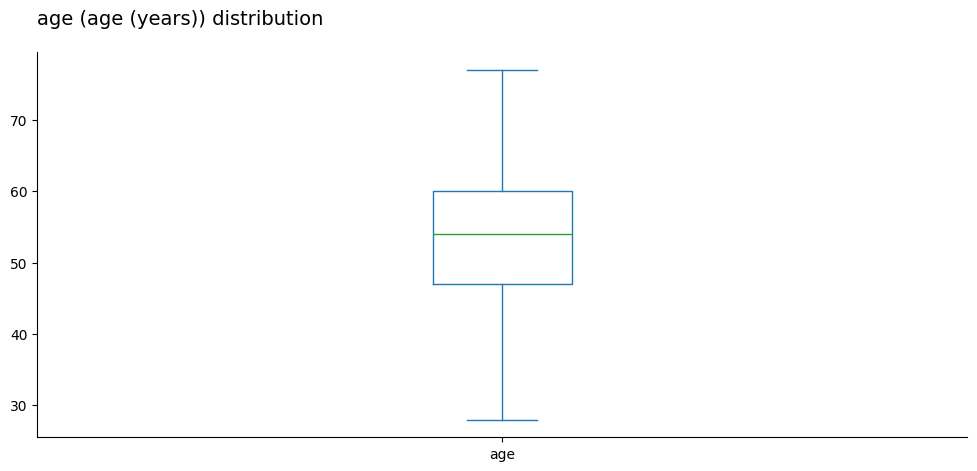

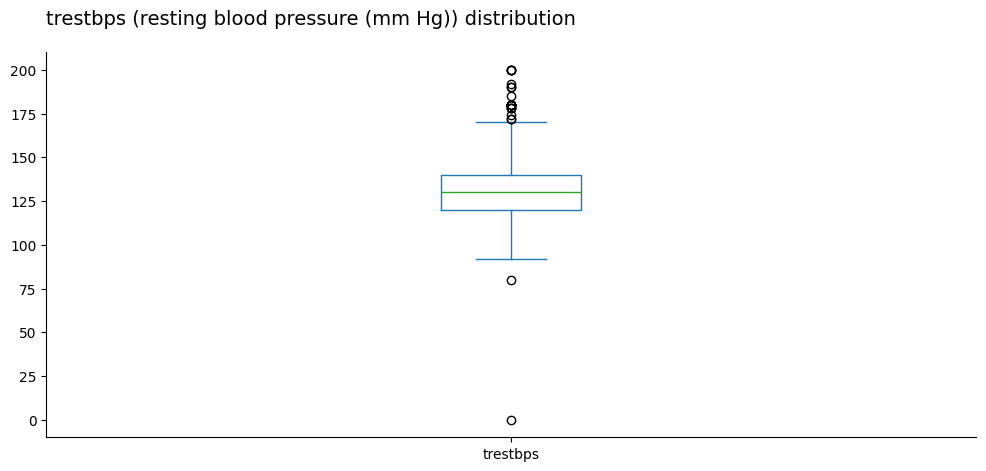

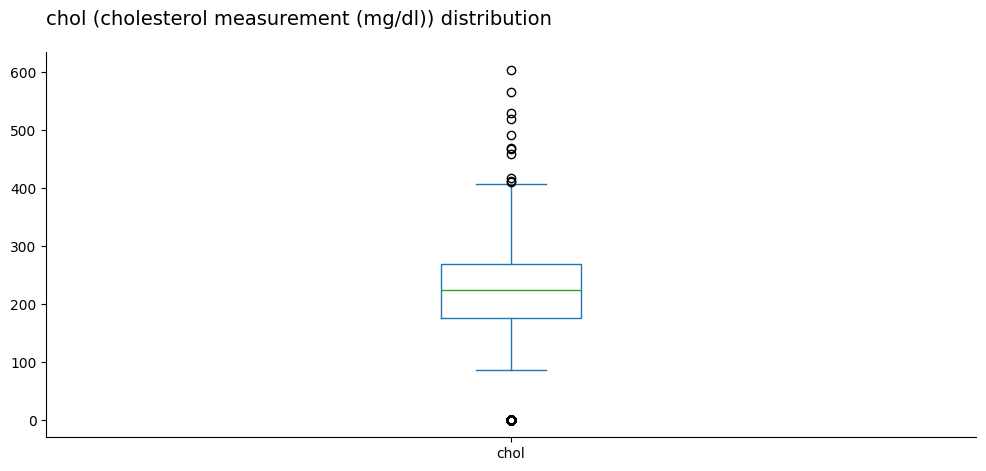

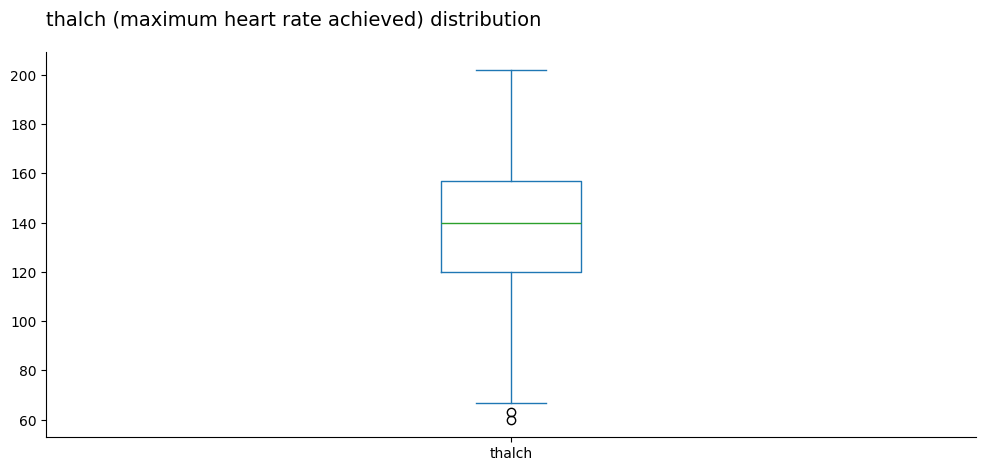

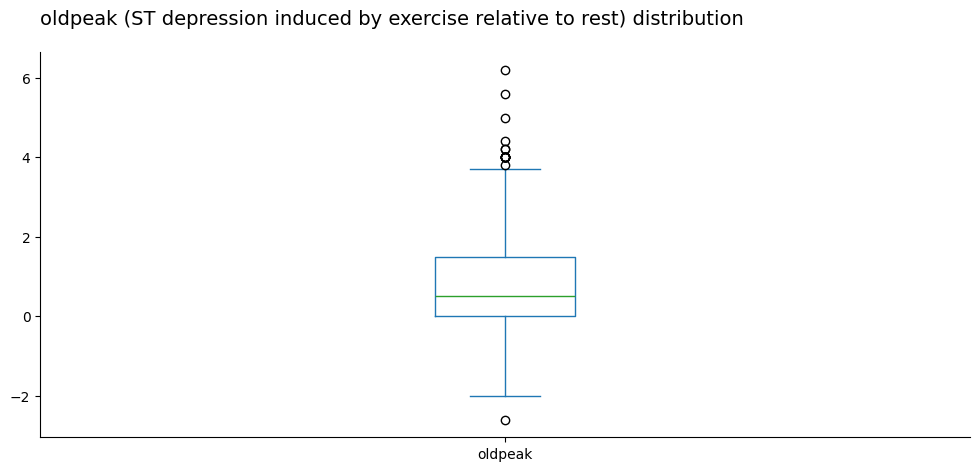

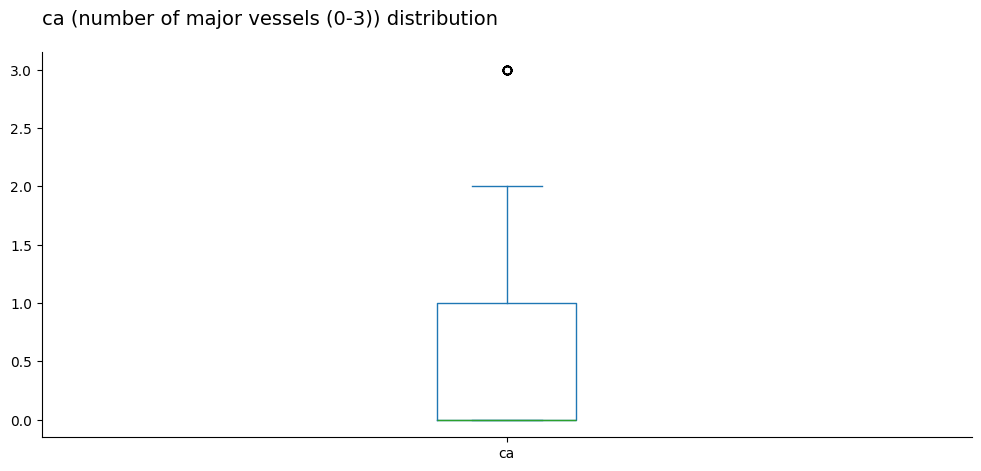

In [9]:
from matplotlib import pyplot as plt

discrete_cols = [
    col for col in df.columns
    if df[col].dtype != "object"
    and col not in ["id"]
]

for col in discrete_cols:
    bins = min(10, df[col].nunique())
    ax = df[col].plot(kind="box", figsize=(12, 5))
    ax.set_title(
        f"{col} ({df.attrs['column_descriptions'].get(col, '')}) distribution",
        fontsize=14,
        loc="left",
        pad=20
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()

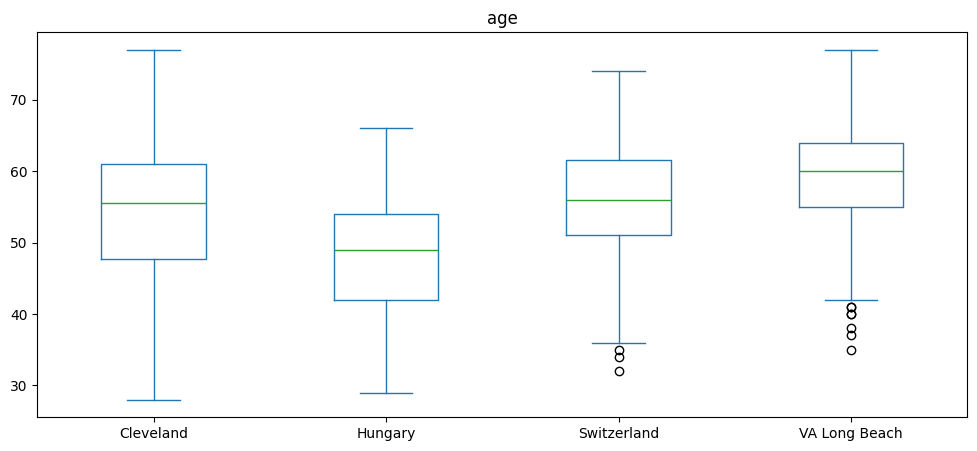

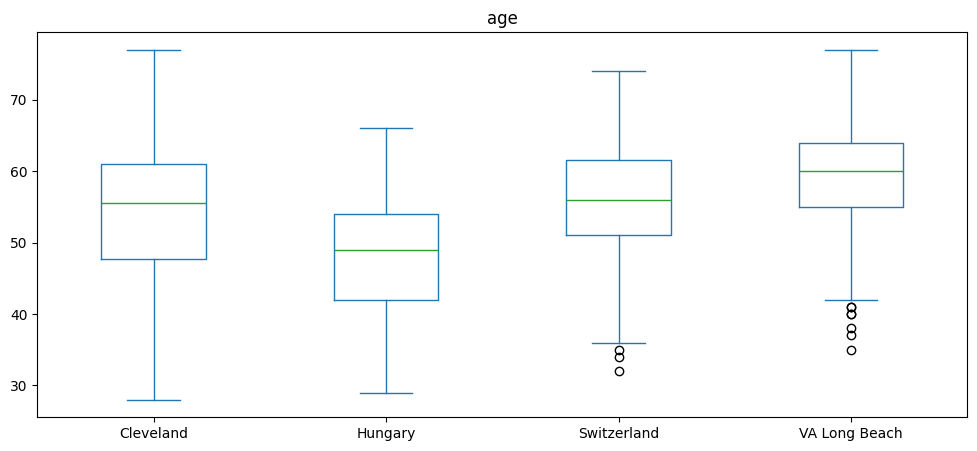

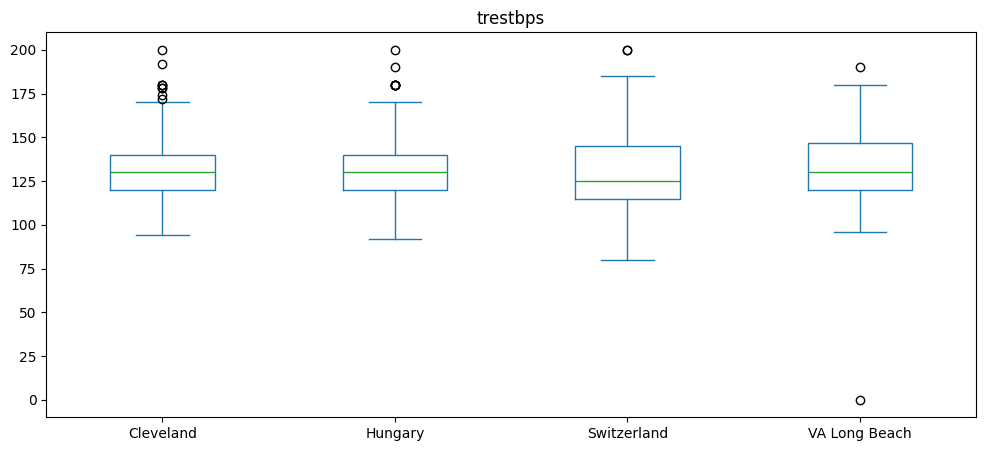

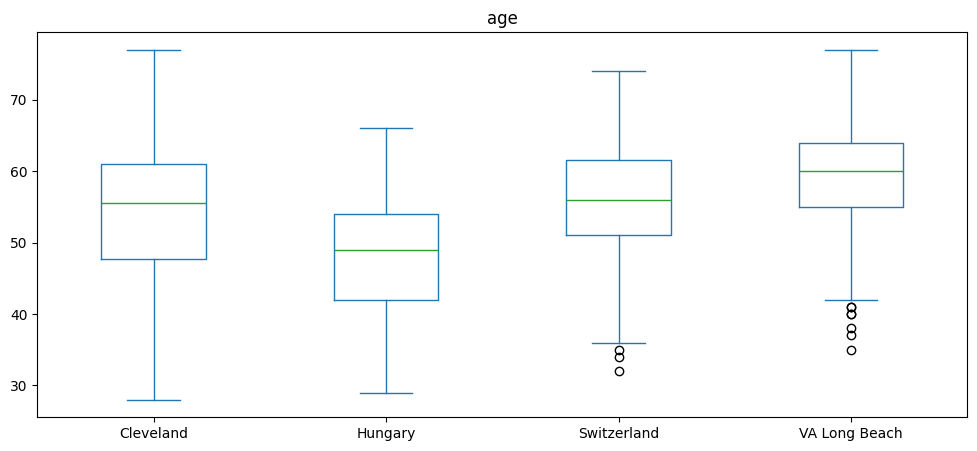

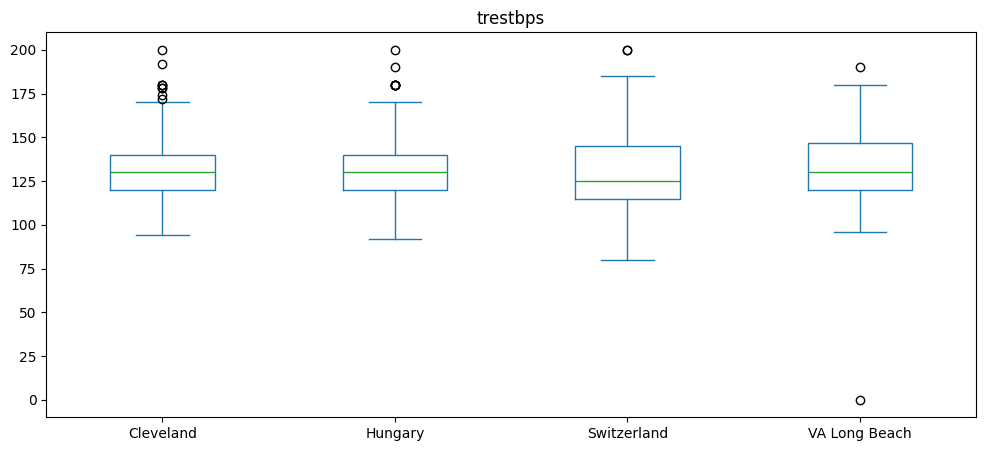

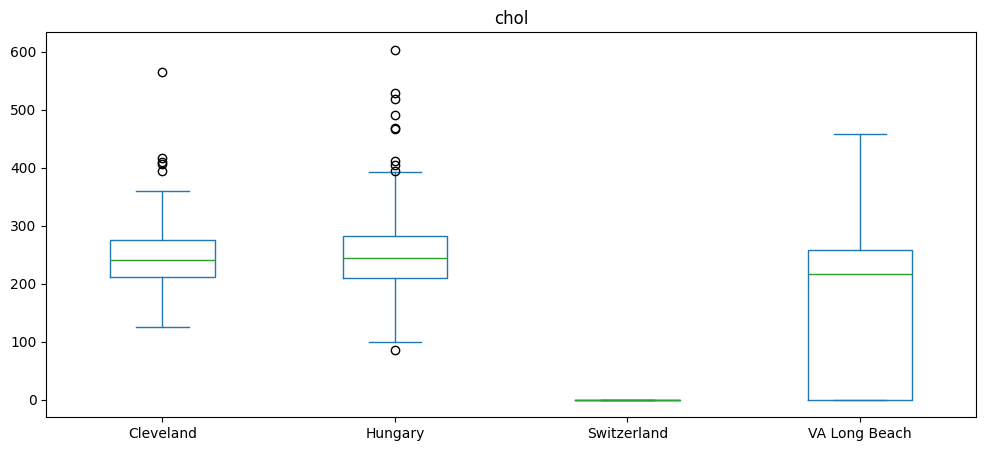

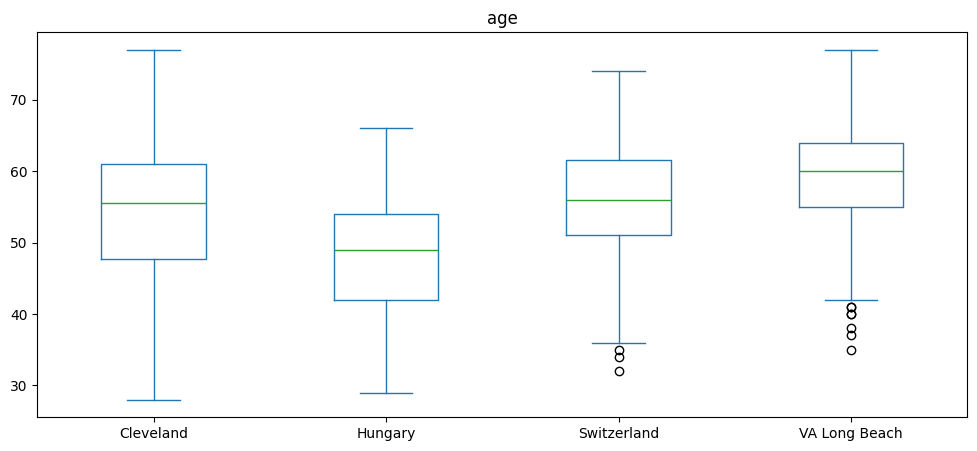

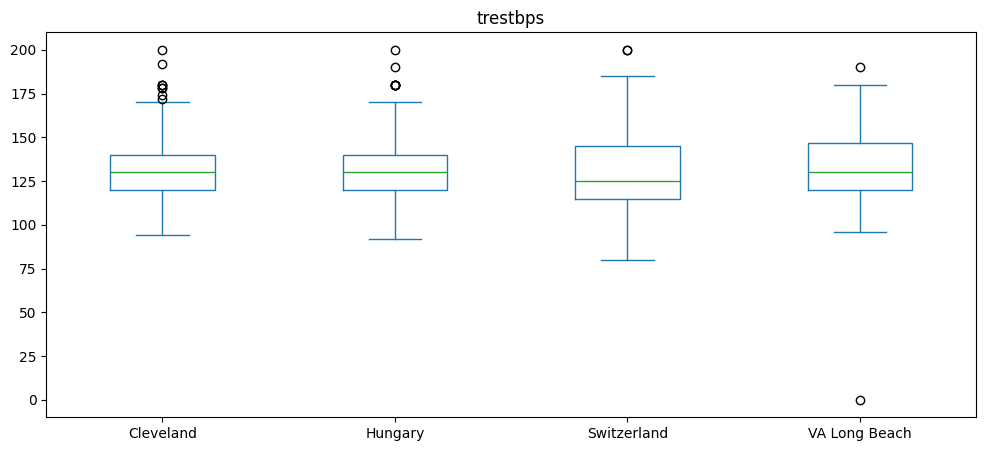

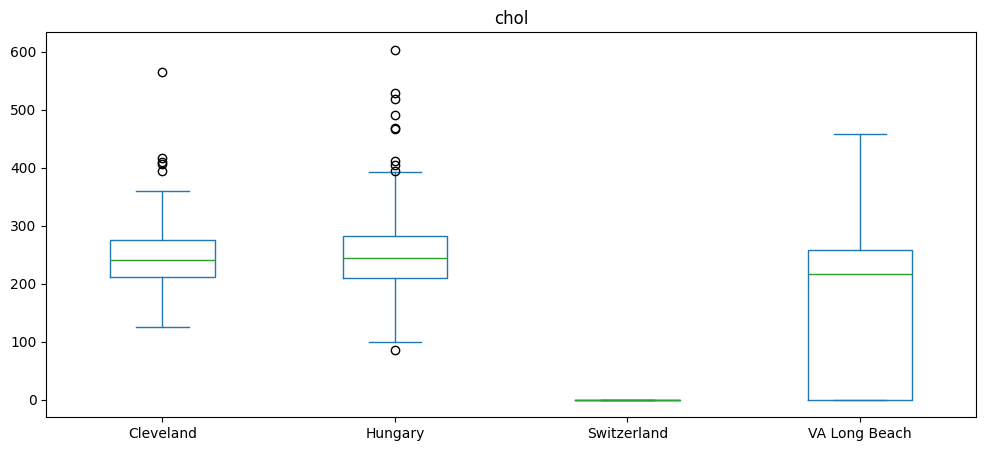

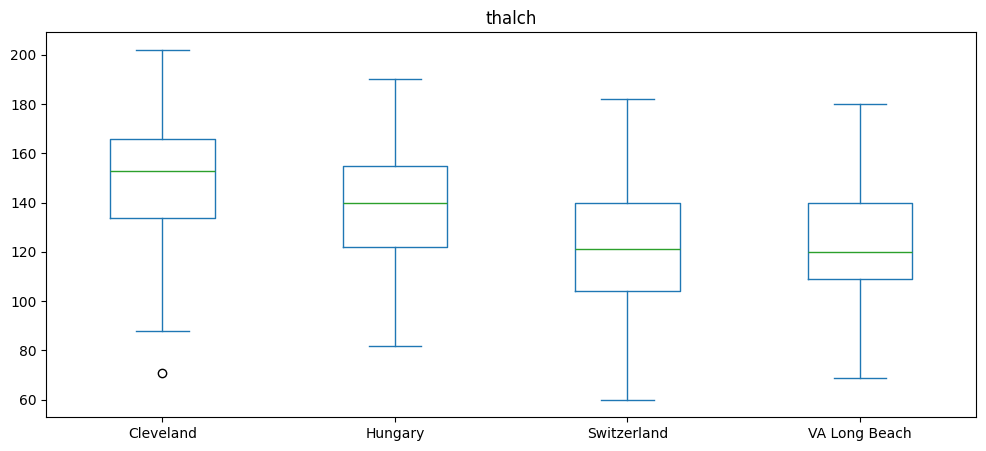

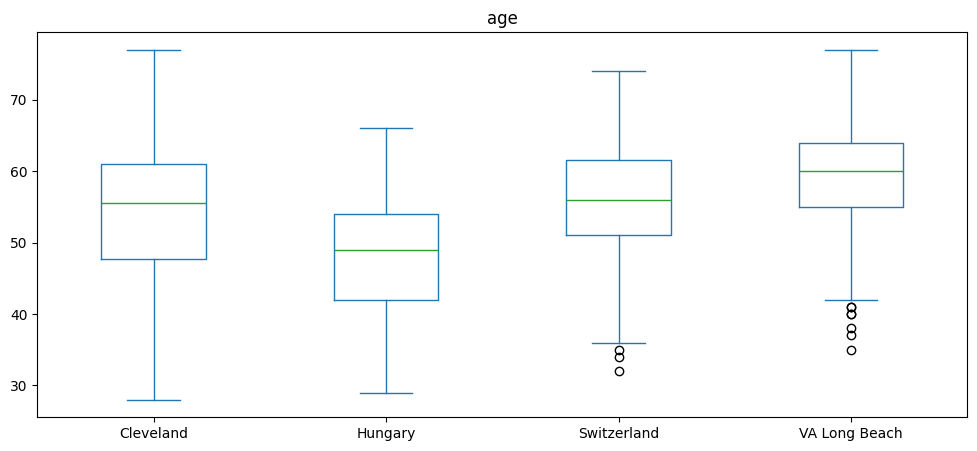

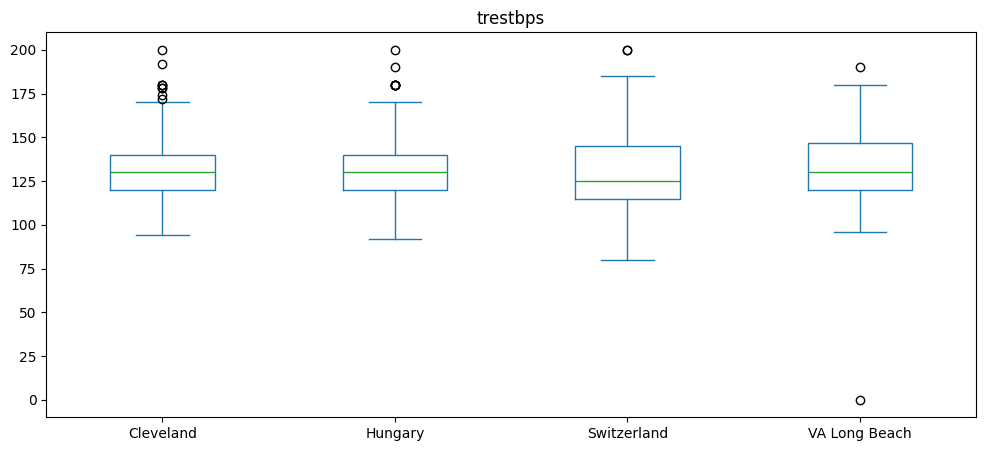

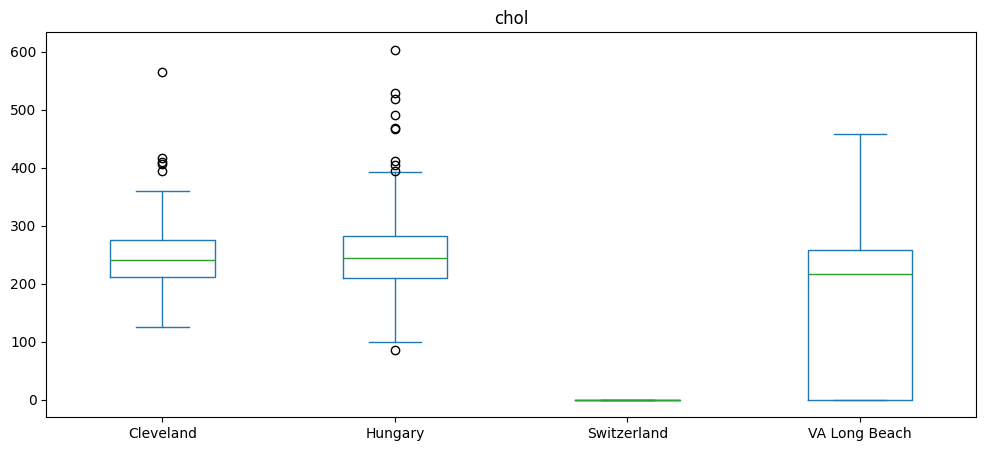

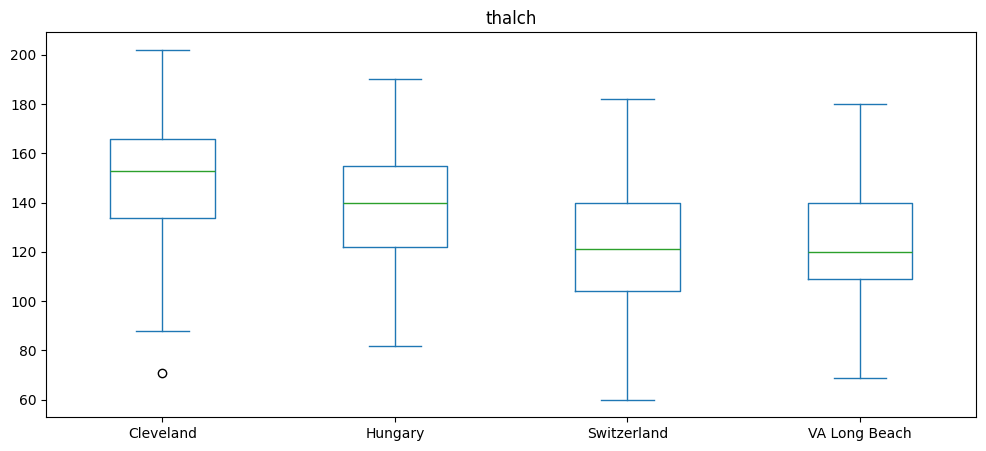

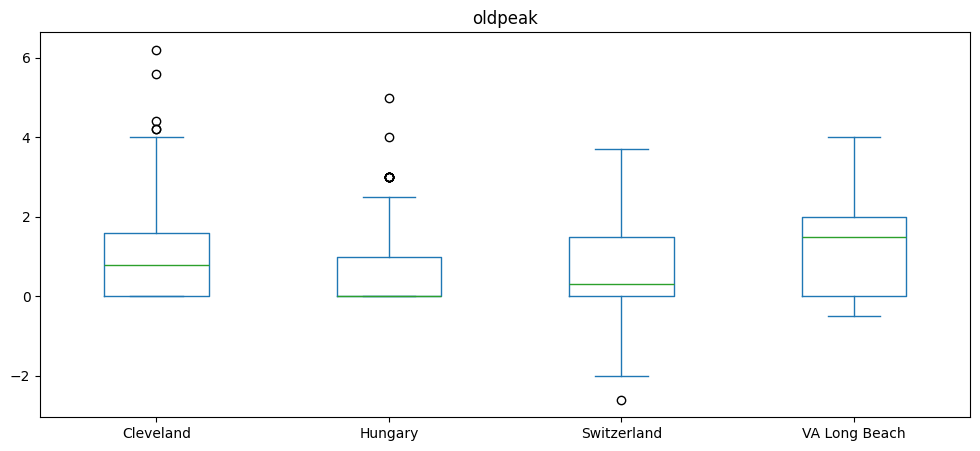

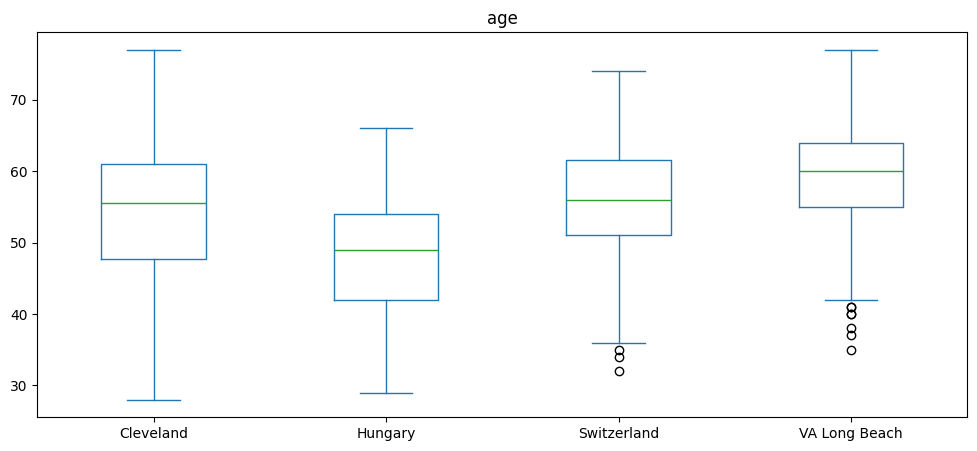

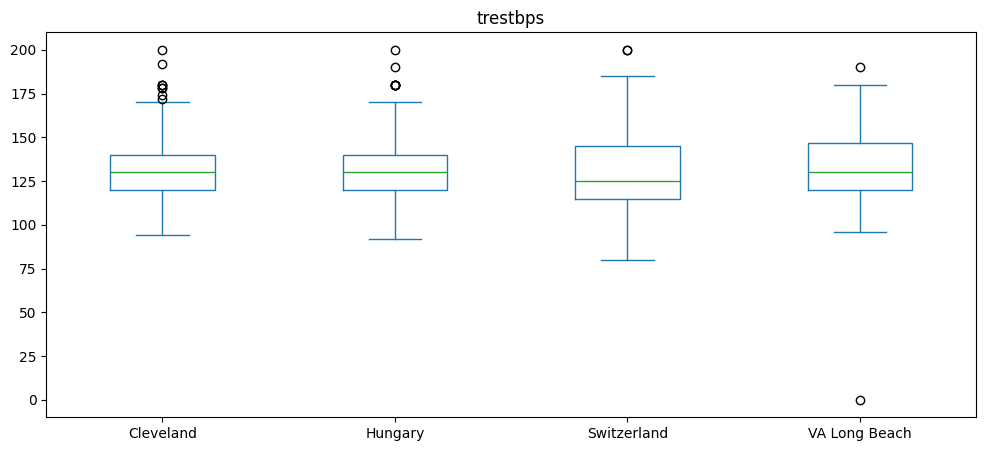

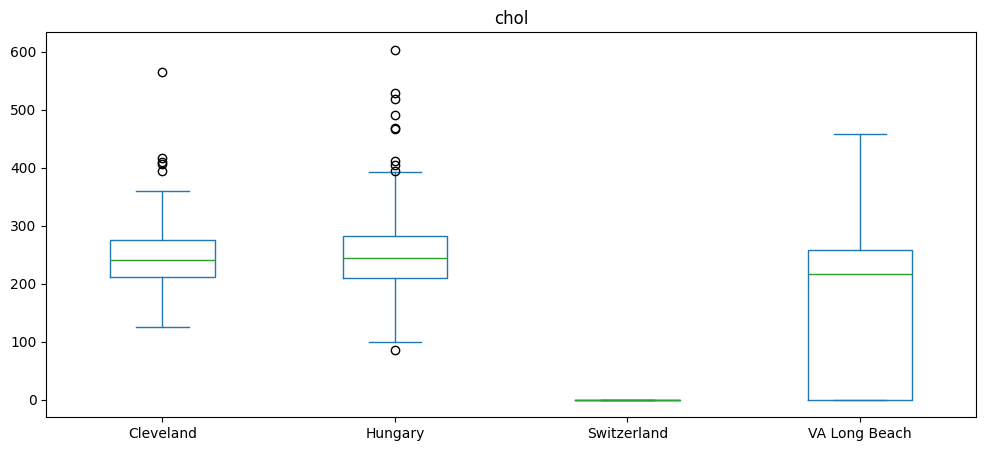

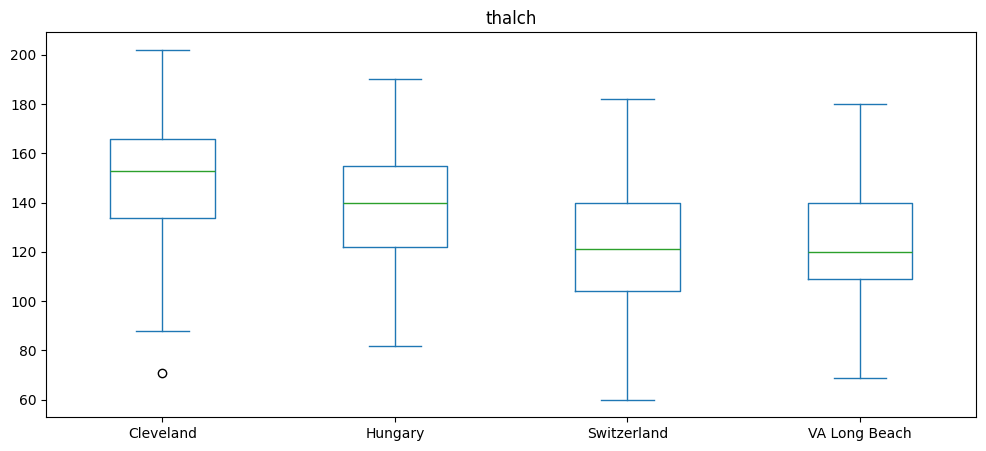

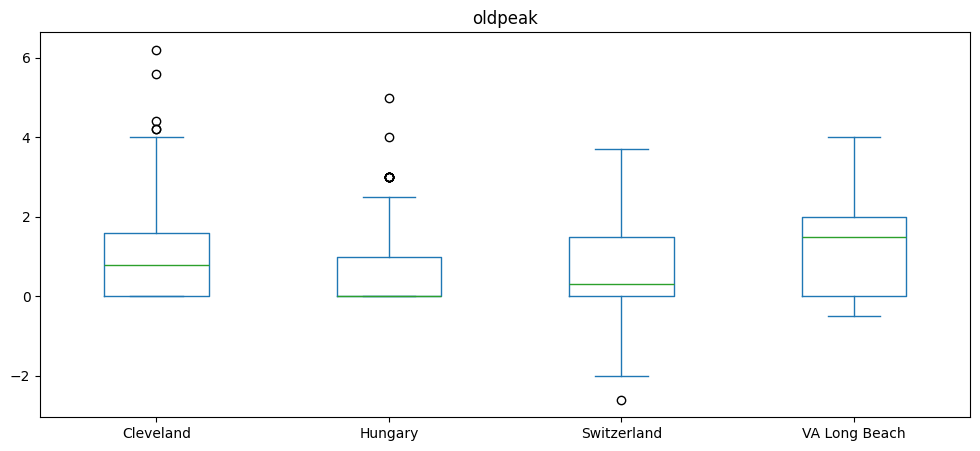

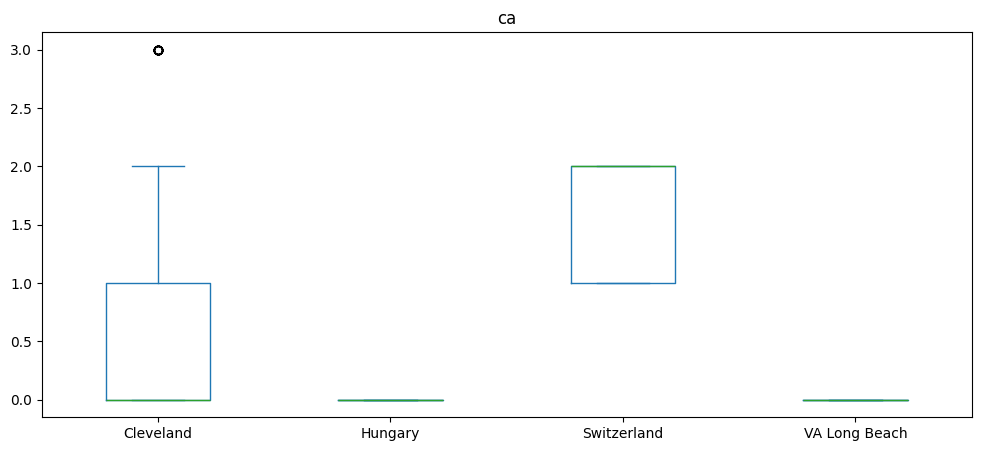

In [10]:
from matplotlib import pyplot as plt

discrete_cols = [
    col for col in df.columns
    if df[col].dtype != "object"
    and col not in ["id"]
]

for col in discrete_cols:
    bins = min(10, df[col].nunique())
    ax = df[[col, "dataset"]].plot(kind="box", figsize=(12, 5), by="dataset")
    # ax.set_title(
    #     f"{col} ({df.attrs['column_descriptions'].get(col, '')}) distribution",
    #     fontsize=14,
    #     loc="left",
    #     pad=20
    # )
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)
    plt.show()

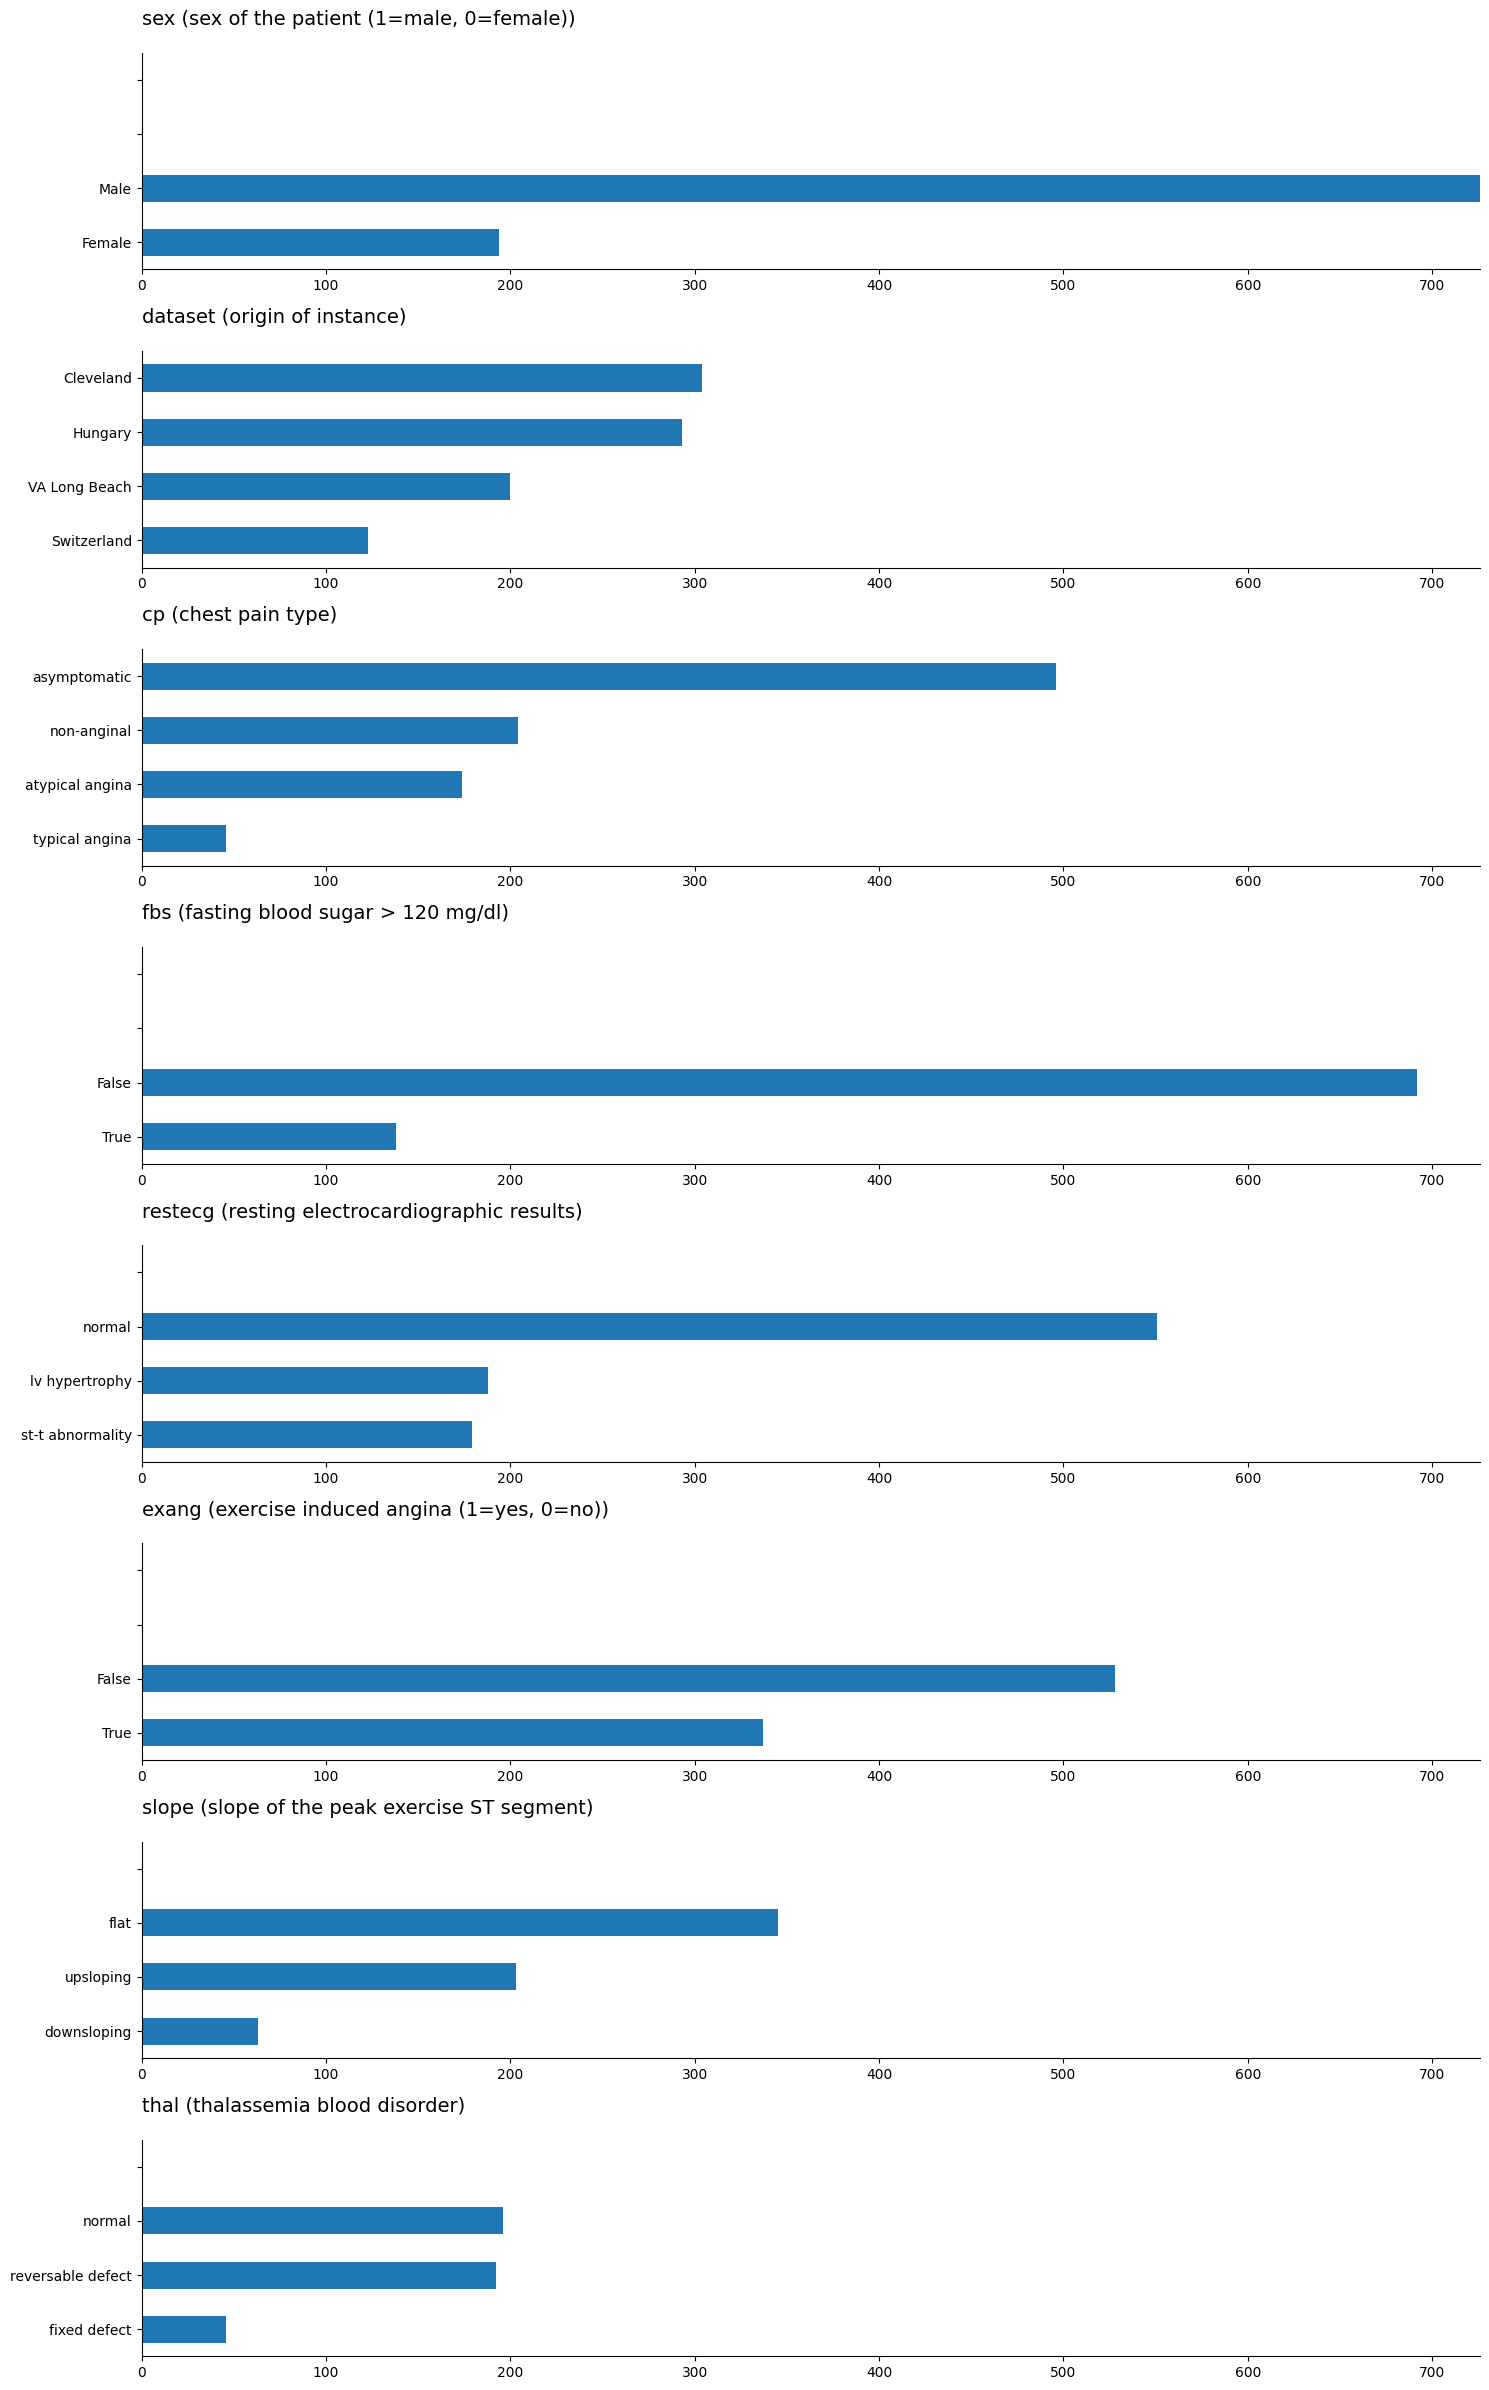

In [134]:
from matplotlib import pyplot as plt
import pandas as pd

categorical_cols = [
    col for col in df.columns if df[col].dtype == "object"
]

max_count = max(
    df[col].value_counts().max()
    for col in categorical_cols
) * 1

max_categories = max(
    df[col].nunique(dropna=True)
    for col in categorical_cols
)

fig, axes = plt.subplots(
    len(categorical_cols),
    1,
    figsize=(15, 3 * len(categorical_cols)),
    # sharex=True
)

if len(categorical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts().sort_values()

    # Pad with empty categories
    counts = counts.reindex(
        list(counts.index) +
        [f"_empty_{i}" for i in range(max_categories - len(counts))],
        fill_value=0
    )

    counts.plot(kind="barh", ax=ax)

    ax.set_xlim(0, max_count)

    # Hide the dummy labels
    labels = [
        "" if str(label).startswith("_empty_") else label
        for label in counts.index
    ]
    ax.set_yticklabels(labels)

    ax.set_title(
        f"{col} ({df.attrs['column_descriptions'].get(col, '')})",
        loc="left",
        fontsize=14, pad=20
    )
    ax.set_ylabel("")
    # if col == categorical_cols[-1]:
    # ax.set_xlabel("Frequency", loc="left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

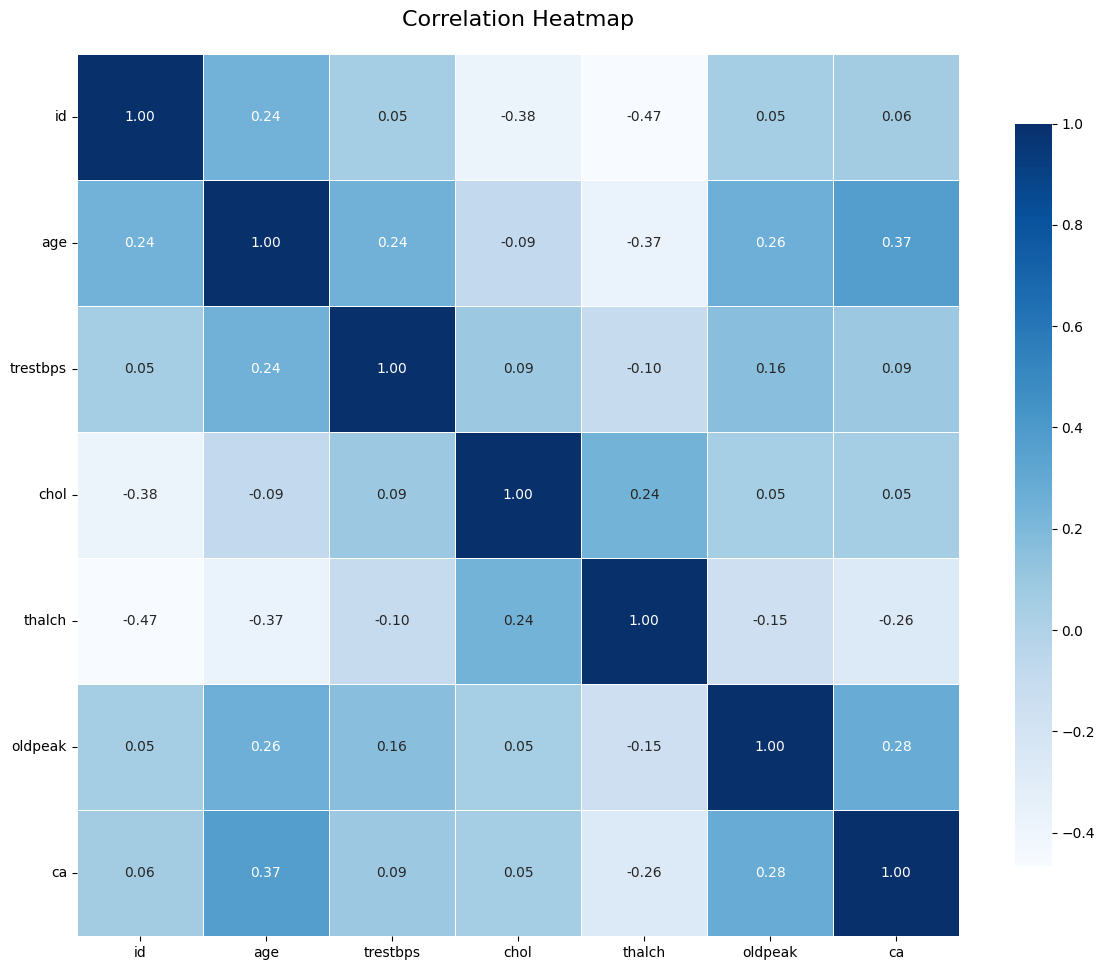

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.title("Correlation Heatmap", fontsize=16, pad=20)

sns.heatmap(
    corr,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=0, ha="center")
plt.yticks(rotation=0)  # horizontal labels

plt.tight_layout()
plt.show()

---
## **4. Data Preparation Pipeline**

In [13]:

import pandas as pd

pd.set_option('future.no_silent_downcasting', True)

categorical_cols = [col for col in df.columns if df[col].dtype == "object"]

print("Null counts in categorical columns:")
print(df[categorical_cols].isnull().sum())
print()

# Columns where nulls mean "test not performed" → fill with "Unknown"
unknown_cols = ["slope", "thal"]

# Columns where nulls are few/random → fill with mode
mode_cols = ["fbs", "restecg", "exang"]

for col in unknown_cols:
    if col in categorical_cols and df[col].isnull().any():
        n_nulls = df[col].isnull().sum()
        df[col] = df[col].fillna("Unknown")
        print(f"  '{col}': filled {n_nulls} nulls with 'Unknown'")

for col in mode_cols:
    if col in categorical_cols and df[col].isnull().any():
        mode_val = df[col].mode()[0]
        n_nulls = df[col].isnull().sum()
        df[col] = df[col].fillna(mode_val)
        print(f"  '{col}': filled {n_nulls} nulls with mode '{mode_val}'")

print("\nRemaining nulls in categorical columns:")
print(df[categorical_cols].isnull().sum())

Null counts in categorical columns:
sex          0
dataset      0
cp           0
fbs         90
restecg      2
exang       55
slope      309
thal       486
dtype: int64

  'slope': filled 309 nulls with 'Unknown'
  'thal': filled 486 nulls with 'Unknown'
  'fbs': filled 90 nulls with mode 'False'
  'restecg': filled 2 nulls with mode 'normal'
  'exang': filled 55 nulls with mode 'False'

Remaining nulls in categorical columns:
sex        0
dataset    0
cp         0
fbs        0
restecg    0
exang      0
slope      0
thal       0
dtype: int64


In [14]:
numeric_cols = [
    col for col in df.columns if df[col].dtype != "object" and col != "id"
]
print("\nNull counts in numeric columns:")
print(df[numeric_cols].isnull().sum())


Null counts in numeric columns:
age           0
trestbps     59
chol         30
thalch       55
oldpeak      62
ca          611
dtype: int64


In [15]:

# Fix null values in numeric columns

# ca: 66% missing — test likely not performed → create missing flag + fill with median
df["ca_missing"] = df["ca"].isnull().astype(int)

# Columns with moderate missingness → fill with median (robust to outliers)
median_cols = ["trestbps", "chol", "thalch", "oldpeak", "ca"]

for col in median_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        n_nulls = df[col].isnull().sum()
        df[col] = df[col].fillna(median_val)
        print(f"  '{col}': filled {n_nulls} nulls with median {median_val}")

print("\nRemaining nulls in numeric columns:")
numeric_cols = [col for col in df.columns if df[col].dtype != "object" and col not in ["id"]]
print(df[numeric_cols].isnull().sum())


  'trestbps': filled 59 nulls with median 130.0
  'chol': filled 30 nulls with median 223.0
  'thalch': filled 55 nulls with median 140.0
  'oldpeak': filled 62 nulls with median 0.5
  'ca': filled 611 nulls with median 0.0

Remaining nulls in numeric columns:
age           0
trestbps      0
chol          0
thalch        0
oldpeak       0
ca            0
ca_missing    0
dtype: int64


In [16]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,ca_missing
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,0
2,2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,0
3,3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,Unknown,0.0,Unknown,1
916,916,62,Male,VA Long Beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,Unknown,0.0,Unknown,1
917,917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,Unknown,0.0,fixed defect,1
918,918,58,Male,VA Long Beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,Unknown,0.0,Unknown,1


In [140]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler

numeric_cols = [
    col
    for col in df.columns
    if df[col].dtype != "object" 
    and col not in ["id"]
]

scaler = Pipeline([
    ("robust", RobustScaler()),   # Step 1: neutralize outliers
    ("minmax", MinMaxScaler()),   # Step 2: force [0, 1] range
])

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [141]:
# One-hot encode categorical columns
categorical_cols = [
    col
    for col in df.columns
    if df[col].dtype == "object"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

In [142]:
df.drop(columns=["id"], inplace=True)
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [143]:
df.columns = df.columns.str.replace(" ", "_").str.replace("-", "_").str.lower()

In [21]:
df

,age,trestbps,chol,thalch,oldpeak,ca,ca_missing,sex_male,dataset_hungary,dataset_switzerland,...,fbs_true,restecg_normal,restecg_st_t_abnormality,exang_true,slope_downsloping,slope_flat,slope_upsloping,thal_fixed_defect,thal_normal,thal_reversable_defect
0,0.714286,0.725,0.386401,0.633803,0.556818,0.000000,0.0,1,0,0,...,1,0,0,0,1,0,0,1,0,0
1,0.795918,0.800,0.474295,0.338028,0.465909,1.000000,0.0,1,0,0,...,0,0,0,1,0,1,0,0,1,0
2,0.795918,0.600,0.379768,0.485915,0.590909,0.666667,0.0,1,0,0,...,0,0,0,1,0,1,0,0,0,1
3,0.183673,0.650,0.414594,0.894366,0.693182,0.000000,0.0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
4,0.265306,0.650,0.338308,0.788732,0.454545,0.000000,0.0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,0.530612,0.635,0.552239,0.661972,0.295455,0.000000,1.0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
916,0.693878,0.650,0.230514,0.563380,0.352273,0.000000,1.0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
917,0.551020,0.610,0.369818,0.281690,0.295455,0.000000,1.0,1,0,0,...,1,0,1,0,0,0,0,1,0,0
918,0.612245,0.650,0.638474,0.563380,0.352273,0.000000,1.0,1,0,0,...,1,0,0,0,0,0,0,0,0,0


In [22]:
import os

import pandas as pd
import plotly.express as px
import plotly.io as pio
import umap
from sklearn.decomposition import PCA

# Paths for saved visualizations
umap_html_path = "../data/clustering_for_heart_disease_analysis_project/umap_projection.html"
umap_json_path = "../data/clustering_for_heart_disease_analysis_project/umap_projection.json"
pca_html_path = "../data/clustering_for_heart_disease_analysis_project/pca_projection.html"
pca_json_path = "../data/clustering_for_heart_disease_analysis_project/pca_projection.json"

# No ground-truth labels exist yet (this is unsupervised clustering),
# so we just visualize structure without color-coding by a target.

# Check if visualizations already exist
if os.path.exists(umap_json_path) and os.path.exists(pca_json_path):
    print("Visualizations already exist. Loading saved figures...")
    print(f"UMAP: {umap_html_path}")
    print(f"PCA: {pca_html_path}")

    fig_umap = pio.read_json(umap_json_path)
    fig_umap.show()

    fig_pca = pio.read_json(pca_json_path)
    fig_pca.show()
else:
    print("Generating visualizations (this may take a while)...")

    print("Running UMAP...")
    reducer_umap = umap.UMAP(n_components=2, random_state=42)
    embed_umap = reducer_umap.fit_transform(df)

    fig_umap = px.scatter(
        x=embed_umap[:, 0], y=embed_umap[:, 1],
        title="UMAP Projection (Heart Disease Dataset)"
    )
    fig_umap.write_html(umap_html_path)
    fig_umap.write_json(umap_json_path)
    print(f"UMAP saved to {umap_html_path} and {umap_json_path}")
    fig_umap.show()

    print("Running PCA...")
    pca = PCA(n_components=2, random_state=42)
    embed_pca = pca.fit_transform(df)

    fig_pca = px.scatter(
        x=embed_pca[:, 0], y=embed_pca[:, 1],
        title="PCA Projection (Heart Disease Dataset)"
    )
    fig_pca.write_html(pca_html_path)
    fig_pca.write_json(pca_json_path)
    print(f"PCA saved to {pca_html_path} and {pca_json_path}")
    fig_pca.show()

    print("Visualizations complete and saved!")

Visualizations already exist. Loading saved figures...
UMAP: ../data/clustering_for_heart_disease_analysis_project/umap_projection.html
PCA: ../data/clustering_for_heart_disease_analysis_project/pca_projection.html


Visualizations already exist. Loading saved figures...
UMAP: ../data/clustering_for_heart_disease_analysis_project/umap_projection.html
PCA: ../data/clustering_for_heart_disease_analysis_project/pca_projection.html


## **5. Model Selection & Training**

In [146]:
# Results funtion to read result json, see if the model is already evaluated,
# if not, evaluate it and save the results to a json file
import json
import os

RESULTS_PATH = (
    "../data/clustering_for_heart_disease_analysis_project/results.json"
)

def load_results():
    if not os.path.exists(RESULTS_PATH):
        return {}
    try:
        with open(RESULTS_PATH, "r") as f:
            content = f.read().strip()
            if not content:
                return {}
            return json.loads(content)
    except json.JSONDecodeError:
        # If the file is empty or corrupted, start fresh
        return {}

def should_evaluate(model_name):
    results = load_results()
    return model_name not in results

def save_results(model_name, metrics, params=None):
    results = load_results()
    results[model_name] = {"metrics": metrics, "params": params}
    with open(RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=4)

### **Cluster Validity Scoring**

Silhouette score alone rewards degenerate solutions: pushing `k` toward `n` creates tiny, ultra-tight clusters that trivially score high, and density-based methods like DBSCAN can inflate their score by labeling most ambiguous points as noise. `cluster_validity_score` keeps silhouette as the core signal but multiplies it by a penalty that shrinks toward 0 as the smallest cluster falls below a minimum size, and invalidates (`-1.0`) solutions with too few clusters or too much noise.

In [147]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score


def cluster_validity_score(
        X, labels, min_cluster_frac=0.05, max_noise_frac=0.30
    ):
    """
    Composite clustering score: silhouette score penalized for tiny/imbalanced
    clusters and (for density-based methods) excessive noise.

    Returns -1.0 for degenerate solutions (fewer than 2 real clusters, or
    noise above `max_noise_frac`). Otherwise returns
    `silhouette_score * size_penalty`, where `size_penalty` shrinks toward 0
    as the smallest cluster gets smaller than `min_cluster_frac * n_samples`,
    and is 1.0 once every cluster meets that minimum size.
    """
    labels = np.asarray(labels)
    n_samples = len(labels)

    mask = labels != -1
    n_clusters = len(set(labels[mask]))

    if n_clusters < 2:
        return -1.0

    noise_frac = 1 - mask.sum() / n_samples
    if noise_frac > max_noise_frac:
        return -1.0

    cluster_sizes = pd.Series(labels[mask]).value_counts()
    min_cluster_size = cluster_sizes.min()
    min_required = max(2, min_cluster_frac * n_samples)

    size_penalty = min(1.0, min_cluster_size / min_required)

    base_score = silhouette_score(X[mask], labels[mask])

    return base_score * size_penalty

In [149]:
import os

import pandas as pd
import plotly.express as px
import plotly.io as pio
import umap
from sklearn.cluster import DBSCAN, KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA

CLUSTER_VIZ_DIR = "../data/clustering_for_heart_disease_analysis_project"


def rebuild_estimator(model_name, params):
    """Re-creates a fitted-ready estimator from a model's saved best params."""
    if model_name == "Kmeans":
        return KMeans(n_clusters=params["n_clusters"], random_state=42)
    if model_name == "Mini Batch KMeans":
        return MiniBatchKMeans(n_clusters=params["n_clusters"], random_state=42)
    if model_name == "DBSCAN":
        return DBSCANEnsemble(
            eps=params["eps"], min_samples=params["min_samples"]
        )
    raise ValueError(f"Unknown model: {model_name}")


def _plot_projection(
        embed, labels_str, model_name, method_name,
        axis_prefix, html_path, json_path
    ):
    """Builds, caches, and shows a single 2D cluster scatter plot."""
    fig = px.scatter(
        x=embed[:, 0], y=embed[:, 1],
        color=labels_str,
        title=f"{model_name} Clusters ({method_name} Projection)",
        labels={
            "color": "Cluster", "x": f"{axis_prefix}1", "y": f"{axis_prefix}2"
        },
    )
    fig.write_html(html_path)
    fig.write_json(json_path)
    print(f"Saved to {html_path} and {json_path}")
    fig.show()


def visualize_model_clusters(model_name, force=False):
    """
    Call this right after a model has been evaluated to see its clusters:
    projects the data to 2D with both UMAP and PCA, and colors each
    projection by `model_name`'s best cluster assignments (noise points, if
    any, shown as their own "Noise" category). Each figure is cached to
    disk, so unless `force=True`, it is only computed once and simply
    reloaded on subsequent runs.
    """
    slug = model_name.lower().replace(" ", "_")
    umap_html_path = f"{CLUSTER_VIZ_DIR}/{slug}_umap_clusters.html"
    umap_json_path = f"{CLUSTER_VIZ_DIR}/{slug}_umap_clusters.json"
    pca_html_path = f"{CLUSTER_VIZ_DIR}/{slug}_pca_clusters.html"
    pca_json_path = f"{CLUSTER_VIZ_DIR}/{slug}_pca_clusters.json"

    if (
        not force
        and os.path.exists(umap_json_path)
        and os.path.exists(pca_json_path)
    ):
        print(f"Loading cached cluster plots for '{model_name}'...")
        pio.read_json(umap_json_path).show()
        pio.read_json(pca_json_path).show()
        return

    results = load_results()
    if model_name not in results:
        print(f"Skipping '{model_name}': not yet evaluated.")
        return

    print(f"Computing cluster plots for '{model_name}'...")
    params = results[model_name]["params"]
    estimator = rebuild_estimator(model_name, params)
    labels = estimator.fit_predict(df)
    labels_str = pd.Series(labels).astype(str).replace("-1", "Noise")

    print("Running UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42)
    embed_umap = reducer.fit_transform(df)
    _plot_projection(
        embed_umap, labels_str, model_name, "UMAP", "UMAP",
        umap_html_path, umap_json_path,
    )

    print("Running PCA...")
    pca = PCA(n_components=2, random_state=42)
    embed_pca = pca.fit_transform(df)
    _plot_projection(
        embed_pca, labels_str, model_name, "PCA", "PC",
        pca_html_path, pca_json_path,
    )


### **K-Means**

In [26]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from skopt import BayesSearchCV
from skopt.space import Integer


def kmeans_scorer(estimator, X):
    """
    Custom scoring function for KMeans using the composite (penalized)
    cluster validity score, so degenerate near-singleton clusters are
    not rewarded even though the full k range up to len(df) is searched.
    """
    labels = estimator.fit_predict(X)
    return cluster_validity_score(X, labels)


model_name = "Kmeans"

if should_evaluate(model_name):

    search_spaces = {
        "n_clusters": Integer(2, len(df) - 1),
    }

    opt = BayesSearchCV(
        estimator=KMeans(random_state=42),
        search_spaces=search_spaces,
        n_iter=50,
        scoring=kmeans_scorer,
        cv=[(np.arange(len(df)), np.arange(len(df)))],
        n_jobs=-1,
        refit=True,
        random_state=42,
    )

    opt.fit(df)

    best_labels = opt.best_estimator_.labels_
    best_silhouette = silhouette_score(df, best_labels)

    print(f"Best parameters: {opt.best_params_}")
    print(f"Best composite (penalized) score: {opt.best_score_:.4f}")
    print(f"Corresponding silhouette score: {best_silhouette:.4f}")

    save_results(
        model_name,
        metrics={
            "silhouette_score": best_silhouette,
            "composite_score": opt.best_score_,
        },
        params=opt.best_params_,
    )

else:
    print(
        f"Model '{model_name}' has already been evaluated. Skipping evaluation."
    )
    previous_results = load_results()[model_name]
    print(f"Best parameters: {previous_results['params']}")
    print(f"Best metrics: {previous_results['metrics']}")

# See the clusters this model found
visualize_model_clusters(model_name, force=False)

Model 'Kmeans' has already been evaluated. Skipping evaluation.
Best parameters: {'n_clusters': 8}
Best metrics: {'silhouette_score': 0.19997250878011485, 'composite_score': 0.19997250878011485}
Loading cached cluster plots for 'Kmeans'...


Model 'Kmeans' has already been evaluated. Skipping evaluation.
Best parameters: {'n_clusters': 8}
Best metrics: {'silhouette_score': 0.19997250878011485, 'composite_score': 0.19997250878011485}
Loading cached cluster plots for 'Kmeans'...


### **Mini Batch K-Means**

In [27]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from skopt import BayesSearchCV
from skopt.space import Integer


def mini_batch_kmeans_scorer(estimator, X):
    """
    Custom scoring function for MiniBatchKMeans using the composite (penalized)
    cluster validity score, so degenerate near-singleton clusters are
    not rewarded even though the full k range up to len(df) is searched.
    """
    labels = estimator.fit_predict(X)
    return cluster_validity_score(X, labels)


model_name = "Mini Batch KMeans"

if should_evaluate(model_name):

    search_spaces = {
        "n_clusters": Integer(2, len(df) - 1),
    }

    opt = BayesSearchCV(
        estimator=MiniBatchKMeans(random_state=42),
        search_spaces=search_spaces,
        n_iter=50,
        scoring=mini_batch_kmeans_scorer,
        cv=[(np.arange(len(df)), np.arange(len(df)))],
        n_jobs=-1,
        refit=True,
        random_state=42,
    )

    opt.fit(df)

    best_labels = opt.best_estimator_.labels_
    best_silhouette = silhouette_score(df, best_labels)

    print(f"Best parameters: {opt.best_params_}")
    print(f"Best composite (penalized) score: {opt.best_score_:.4f}")
    print(f"Corresponding silhouette score: {best_silhouette:.4f}")

    save_results(
        model_name,
        metrics={
            "silhouette_score": best_silhouette,
            "composite_score": opt.best_score_,
        },
        params=opt.best_params_,
    )

else:
    print(
        f"Model '{model_name}' has already been evaluated. Skipping evaluation."
    )
    previous_results = load_results()[model_name]
    print(f"Best parameters: {previous_results['params']}")
    print(f"Best metrics: {previous_results['metrics']}")

# See the clusters this model found
visualize_model_clusters(model_name, force=False)

Model 'Mini Batch KMeans' has already been evaluated. Skipping evaluation.
Best parameters: {'n_clusters': 5}
Best metrics: {'silhouette_score': 0.18784127852969473, 'composite_score': 0.18784127852969473}
Loading cached cluster plots for 'Mini Batch KMeans'...


Model 'Mini Batch KMeans' has already been evaluated. Skipping evaluation.
Best parameters: {'n_clusters': 5}
Best metrics: {'silhouette_score': 0.18784127852969473, 'composite_score': 0.18784127852969473}
Loading cached cluster plots for 'Mini Batch KMeans'...


### **DBSCAN**

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier


def assign_noise_to_nearest_cluster(X, labels, n_neighbors=5):
    """
    Reassigns DBSCAN noise points (-1) to their nearest cluster, so every
    point ends up with a cluster label - just like K-Means/MiniBatchKMeans,
    which always assign every point.
    """
    labels = np.asarray(labels).copy()
    noise_mask = labels == -1

    if not noise_mask.any() or noise_mask.all():
        # Nothing to reassign (no noise), or nothing to learn from
        # (everything is noise) - return labels unchanged either way.
        return labels

    clf = KNeighborsClassifier(
        n_neighbors=min(n_neighbors, (~noise_mask).sum()),
        weights='distance'
    )
    clf.fit(X[~noise_mask], labels[~noise_mask])
    labels[noise_mask] = clf.predict(X[noise_mask])

    return labels


class DBSCANEnsemble(BaseEstimator, ClusterMixin):
    """
    DBSCAN combined with automatic noise reassignment into a single
    estimator: any point DBSCAN marks as noise (-1) gets folded into its
    nearest real cluster via a k-NN vote, so `fit_predict` always returns
    a fully-assigned labeling (no -1) - directly comparable to K-Means/
    MiniBatchKMeans. Wrapping this as one estimator means the
    hyperparameter search (`eps`, `min_samples`) evaluates and optimizes
    the *final* labeling we'll actually use, instead of the raw,
    noise-containing DBSCAN output.
    """

    def __init__(self, eps=0.5, min_samples=5, n_neighbors=5):
        self.eps = eps
        self.min_samples = min_samples
        self.n_neighbors = n_neighbors

    def fit(self, X, y=None):
        self.fit_predict(X)
        return self

    def fit_predict(self, X, y=None):
        X = np.asarray(X)
        self.raw_labels_ = DBSCAN(
            eps=self.eps, min_samples=self.min_samples, n_jobs=-1
        ).fit_predict(X)
        self.labels_ = assign_noise_to_nearest_cluster(
            X, self.raw_labels_, n_neighbors=self.n_neighbors
        )
        return self.labels_


In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real


def dbscan_ensemble_scorer(estimator, X):
    """
    Scores the DBSCANEnsemble (DBSCAN + noise reassignment) using the
    composite (penalized) cluster validity score computed on the FINAL,
    fully-assigned labels - so the search directly optimizes the labeling
    we'll actually use, not the raw, noise-containing DBSCAN output.
    """
    labels = estimator.fit_predict(X)
    return cluster_validity_score(X, labels)


model_name = "DBSCAN"

if should_evaluate(model_name):

    # DBSCAN's eps is highly data-dependent, so guessing a fixed range
    # tends to either merge everything into one giant cluster (eps too
    # large) or label everything as noise (eps too small). Instead, derive
    # sensible bounds from the k-th nearest neighbor distance distribution
    # (a standard DBSCAN heuristic): for every point, compute the distance
    # to its k-th closest neighbor, sort those distances, and take a low
    # percentile range as the eps search space - that's roughly where the
    # "dense enough to be a cluster" vs "sparse/noise" transition happens.
    from sklearn.neighbors import NearestNeighbors

    k_for_eps = 10
    neighbors = NearestNeighbors(n_neighbors=k_for_eps).fit(df)
    k_distances, _ = neighbors.kneighbors(df)
    k_distances = np.sort(k_distances[:, -1])

    eps_low = np.percentile(k_distances, 5)
    eps_high = np.percentile(k_distances, 90)

    print(
        f"Data-driven eps search range ({k_for_eps}-NN distances, "
        f"5th-90th percentile): [{eps_low:.4f}, {eps_high:.4f}]"
    )

    search_spaces = {
        "eps": Real(eps_low, eps_high, prior="log-uniform"),
        "min_samples": Integer(2, 15),
    }

    opt = BayesSearchCV(
        estimator=DBSCANEnsemble(),
        search_spaces=search_spaces,
        n_iter=50,
        scoring=dbscan_ensemble_scorer,
        cv=[(np.arange(len(df)), np.arange(len(df)))],
        n_jobs=-1,
        refit=True,
        random_state=42,
    )

    opt.fit(df)

    # opt.best_estimator_ is a fitted DBSCANEnsemble: .labels_ is already
    # the final, fully-assigned labeling (noise reassigned); .raw_labels_
    # is the original DBSCAN output (with -1 for noise), kept only for
    # reporting the noise fraction.
    best_labels = opt.best_estimator_.labels_
    raw_labels = opt.best_estimator_.raw_labels_

    n_clusters = len(set(best_labels))
    noise_frac = float((raw_labels == -1).mean())

    if n_clusters < 2:
        full_silhouette = float("nan")
        full_composite_score = -1.0
        print(
            f"Warning: best DBSCAN solution has only {n_clusters} real "
            "cluster(s), so silhouette score is undefined."
        )
    else:
        full_silhouette = silhouette_score(df.values, best_labels)
        full_composite_score = cluster_validity_score(df.values, best_labels)

    print(f"Best parameters: {opt.best_params_}")
    print(f"Search composite (penalized) score: {opt.best_score_:.4f}")
    print(f"Final silhouette score (noise reassigned): {full_silhouette:.4f}")
    print(f"Final composite (penalized) score (noise reassigned): {full_composite_score:.4f}")
    print(f"Number of clusters found: {n_clusters}")
    print(f"Noise fraction (before reassignment): {noise_frac:.2%}")

    save_results(
        model_name,
        metrics={
            "silhouette_score": full_silhouette,
            "composite_score": full_composite_score,
            "n_clusters": n_clusters,
            "noise_fraction": noise_frac,
        },
        params=opt.best_params_,
    )

else:
    print(
        f"Model '{model_name}' has already been evaluated. Skipping evaluation."
    )
    previous_results = load_results()[model_name]
    print(f"Best parameters: {previous_results['params']}")
    print(f"Best metrics: {previous_results['metrics']}")

# See the clusters this model found
visualize_model_clusters(model_name, force=True)

    # "DBSCAN": {
    #     "metrics": {
    #         "silhouette_score": 0.12215392319495268,
    #         "composite_score": 0.10622080277821973,
    #         "n_clusters": 5,
    #         "noise_fraction": 0.12391304347826088
    #     },
    #     "params": {
    #         "eps": 1.3716676133667536,
    #         "min_samples": 11
    #     }
    # }


Data-driven eps search range (10-NN distances, 5th-90th percentile): [0.2328, 1.4898]
Best parameters: OrderedDict([('eps', 1.3716676133667536), ('min_samples', 11)])
Search composite (penalized) score: 0.1062
Final silhouette score (noise reassigned): 0.1222
Final composite (penalized) score (noise reassigned): 0.1062
Number of clusters found: 5
Noise fraction (before reassignment): 12.39%
Computing cluster plots for 'DBSCAN'...
Running UMAP...


Data-driven eps search range (10-NN distances, 5th-90th percentile): [0.2328, 1.4898]
Best parameters: OrderedDict([('eps', 1.3716676133667536), ('min_samples', 11)])
Search composite (penalized) score: 0.1062
Final silhouette score (noise reassigned): 0.1222
Final composite (penalized) score (noise reassigned): 0.1062
Number of clusters found: 5
Noise fraction (before reassignment): 12.39%
Computing cluster plots for 'DBSCAN'...
Running UMAP...


c:\Users\david\Documents\Courses\MachineLearningPortfolio\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Data-driven eps search range (10-NN distances, 5th-90th percentile): [0.2328, 1.4898]
Best parameters: OrderedDict([('eps', 1.3716676133667536), ('min_samples', 11)])
Search composite (penalized) score: 0.1062
Final silhouette score (noise reassigned): 0.1222
Final composite (penalized) score (noise reassigned): 0.1062
Number of clusters found: 5
Noise fraction (before reassignment): 12.39%
Computing cluster plots for 'DBSCAN'...
Running UMAP...


c:\Users\david\Documents\Courses\MachineLearningPortfolio\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



...

Running PCA...
Saved to ../data/clustering_for_heart_disease_analysis_project/dbscan_pca_clusters.html and ../data/clustering_for_heart_disease_analysis_project/dbscan_pca_clusters.json


Data-driven eps search range (10-NN distances, 5th-90th percentile): [0.2328, 1.4898]
Best parameters: OrderedDict([('eps', 1.3716676133667536), ('min_samples', 11)])
Search composite (penalized) score: 0.1062
Final silhouette score (noise reassigned): 0.1222
Final composite (penalized) score (noise reassigned): 0.1062
Number of clusters found: 5
Noise fraction (before reassignment): 12.39%
Computing cluster plots for 'DBSCAN'...
Running UMAP...


c:\Users\david\Documents\Courses\MachineLearningPortfolio\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Saved to ../data/clustering_for_heart_disease_analysis_project/dbscan_umap_clusters.html and ../data/clustering_for_heart_disease_analysis_project/dbscan_umap_clusters.json


Running PCA...
Saved to ../data/clustering_for_heart_disease_analysis_project/dbscan_pca_clusters.html and ../data/clustering_for_heart_disease_analysis_project/dbscan_pca_clusters.json
